# Модель мира (RSSM) + оценка целей через CLIP в MiniGrid

В рамках данной работы хотелось проверить одну гипотезу: можно ли задать агенту цель словами и довести его
до неё, если оценивать зрительно-языковой моделью не то, что он видит сейчас, а то, что он
увидит через несколько шагов. То есть агент воображает будущее внутри своей модели мира, а
CLIP смотрит на это воображаемое будущее и говорит, насколько оно похоже на цель.

Если коротко, конвейер такой:
- наблюдение (полный RGB-кадр сетки) кодируется в скрытое состояние модели мира;
- из этого состояния по заданной последовательности действий раскручивается развёртка на
  горизонт H — без обращения к среде, чисто «в голове» модели;
- предсказанные кадры декодируются, и CLIP превращает каждый в число от 0 до 1;
- планировщик перебирает несколько последовательностей, берёт лучшую по этому числу, делает её
  первый шаг и всё повторяется.

Сравниватся три способа выбирать действия: случайные действия (базовый уровень), награда, предсказанная самой
моделью мира, и оценка CLIP.



## Зависимости

In [1]:
!pip -q install "gymnasium>=1.0" "minigrid>=3.0" "transformers>=4.40" imageio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 47.2 MB/s eta 0:00:00


## Конфигурация

Объявляю гиперпараметры. Из всего набора на поведение сильнее всего
влияют: горизонт H, число перебираемых последовательностей и способ, которым оценки
CLIP по кадрам развёртки сворачиваются в одно число.

In [3]:
from dataclasses import dataclass, field, replace


@dataclass
class Config:
    env_id: str = "MiniGrid-Empty-8x8-v0"
    tile_size: int = 8 # размер клетки
    image_size: int = 64  # сторона кадра
    actions: tuple = (0, 1, 2)

    n_episodes: int = 500  # сколько случайных эпизодов собрать
    max_steps: int = 128  # ограничение длины эпизода

    embed_dim: int = 1024  # размер выхода энкодера
    deter_dim: int = 256 # размерность детерминированного состояния
    stoch_dim: int = 32 # размерность стохастического состояния
    hidden_dim: int = 256  # ширина MLP внутри RSSM
    cnn_depth: int = 32  # базовое число каналов CNN

    batch_size: int = 32
    seq_len: int = 32
    train_steps: int = 30000
    lr: float = 3e-4
    kl_scale: float = 1.0
    kl_balance: float = 0.8
    free_nats: float = 3.0
    grad_clip: float = 100.0

    horizon: int = 12   # горизонт воображаемой развёртки
    n_candidates: int = 64  # число перебираемых последовательностей
    cem_iterations: int = 0
    cem_elites: int = 8

    clip_model: str = "openai/clip-vit-base-patch32"
    positive_prompts: tuple = (
        "a red triangle on top of a green square",
    )
    negative_prompts: tuple = (
        "a red triangle and a green square far apart",
    )
    # способ агрегирования оценки кадров развёртки: last_max, sum или discounted
    vlm_aggregate: str = "last_max"
    vlm_discount: float = 0.95

    eval_episodes: int = 20
    eval_seeds: tuple = field(default_factory=lambda: tuple(range(20)))

    seed: int = 0
    device: str = "auto"
    ckpt_path: str = "checkpoints/wm.pt"
    data_path: str = "data/rollouts.npz"


def tiny_config() -> Config:
    """Мини-конфиг для фоллбэка на локальные тесты."""
    return replace(
        Config(),
        env_id="MiniGrid-Empty-6x6-v0",
        image_size=48, # Empty-6x6 при размере клетки 8 даёт кадр 48x48
        n_episodes=5,
        max_steps=32,
        train_steps=50,
        batch_size=4,
        seq_len=12,
        horizon=6,
        n_candidates=8,
        eval_episodes=2,
        eval_seeds=(0, 1),
    )


def resolve_device(device: str = "auto") -> str:
    import torch

    if device != "auto":
        return device
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

## Среда и наблюдения

Среда - MiniGrid: основная Empty-8x8, для быстрых прогонов Empty-6x6. Важный момент: наблюдением
я беру не частичный символьный вид, а полный цветной рендер всей сетки, тк CLIP
училась на картинках, и я хочу, чтобы модель мира и оценщик смотрели ровно на то же изображение,
что и я сама.

Действия оставляем три: повернуть налево, направо, шагнуть вперёд. Подсветку поля зрения агента выключаю, чтобы кадр был однородным и не путал ни CLIP, ни
реконструкцию.

In [4]:
# среду оборачиваю так, чтобы наблюдением был весь кадр сетки в RGB
import numpy as np
import gymnasium as gym
from minigrid.wrappers import RGBImgObsWrapper, ImgObsWrapper


def make_env(env_id: str, tile_size: int = 8, max_steps: int | None = None,
             highlight: bool = False, render_mode: str | None = None):
    """Создаёт MiniGrid env, отдающий полный RGB-кадр сетки (без mission-поля).

    RGBImgObsWrapper рисует всю сетку целиком -> кадр (W*tile)x(H*tile)x3.
    ImgObsWrapper убирает словарь и оставляет только image.
    highlight=False отключает затемнение области видимости агента, чтобы кадр
    был чистым как для CLIP, так и для реконструкции модели мира.
    """
    kwargs = {"render_mode": render_mode}
    if max_steps is not None:
        kwargs["max_steps"] = max_steps
    env = gym.make(env_id, **kwargs)
    # отключаем подсветку FOV на уровне базового окружения
    env.unwrapped.highlight = highlight
    env = RGBImgObsWrapper(env, tile_size=tile_size)
    env = ImgObsWrapper(env)
    return env


def infer_image_size(env_id: str, tile_size: int = 8) -> int:
    env = make_env(env_id, tile_size=tile_size)
    obs, _ = env.reset(seed=0)
    env.close()
    return int(obs.shape[0])


def obs_to_float(obs: np.ndarray) -> np.ndarray:
    x = obs.astype(np.float32) / 255.0
    return np.transpose(x, (2, 0, 1))


def float_to_uint8(img: np.ndarray) -> np.ndarray:
    x = np.clip(img, 0.0, 1.0)
    x = np.transpose(x, (1, 2, 0))
    return (x * 255.0).astype(np.uint8)

## Сбор данных

Модель мира учится предсказывать, что будет после действия, поэтому ей нужны переходы между
кадрами. Собираю их случайно - для пустой комнаты этого хватает, чтобы модель
увиделп разные положения агента.



In [5]:
# сбор данных случайной политикой + сэмплер окон для обучения модели мира
import os
import numpy as np
from tqdm import trange



def collect_random(env_id: str, n_episodes: int, max_steps: int,
                   actions: tuple, tile_size: int = 8, seed: int = 0,
                   out_path: str | None = None):
    """Собирает n_episodes случайных эпизодов и сохраняет их последовательности.

    На каждом шаге действие берётся равномерно из разрешённого набора actions
    ({left, right, forward}). Сохраняем кадр ДО действия, само действие, reward
    и флаг завершения. Так последовательность (o_t, a_t, r_t) годится для
    обучения модели мира предсказывать o_{t+1}.

    Возвращает dict с массивами переменной длины (по эпизодам).
    """
    env = make_env(env_id, tile_size=tile_size, max_steps=max_steps)
    rng = np.random.default_rng(seed)
    actions = np.asarray(actions)

    ep_obs, ep_act, ep_rew, ep_done = [], [], [], []
    for ep in trange(n_episodes, desc="collect"):
        # своё зерно на каждый сброс, чтобы менять стартовое положение агента
        obs, _ = env.reset(seed=int(seed * 100000 + ep))
        obs_list, act_list, rew_list, done_list = [], [], [], []
        done = False
        while not done:
            a = int(rng.choice(actions))
            obs_list.append(obs_to_float(obs))          # кадр ДО действия
            next_obs, r, term, trunc, _ = env.step(a)
            done = term or trunc
            act_list.append(a)
            rew_list.append(float(r))
            done_list.append(bool(done))
            obs = next_obs
        # добавляем финальный кадр, чтобы длина obs = длина действий + 1
        obs_list.append(obs_to_float(obs))
        ep_obs.append(np.asarray(obs_list, dtype=np.float32))
        ep_act.append(np.asarray(act_list, dtype=np.int64))
        ep_rew.append(np.asarray(rew_list, dtype=np.float32))
        ep_done.append(np.asarray(done_list, dtype=bool))
    env.close()

    data = {"obs": ep_obs, "act": ep_act, "rew": ep_rew, "done": ep_done}
    if out_path is not None:
        os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
        # object-массивы, т.к. эпизоды разной длины
        np.savez_compressed(
            out_path,
            obs=_to_object_array(ep_obs),
            act=_to_object_array(ep_act),
            rew=_to_object_array(ep_rew),
            done=_to_object_array(ep_done),
        )
        print(f"сохранено {n_episodes} эпизодов -> {out_path}")
    return data


def _to_object_array(list_of_arrays):
    """1-D object-массив из списка ndarray разной длины.

    Прямой np.array(list, dtype=object) при ОДИНАКОВЫХ длинах эпизодов
    схлопывает список в многомерный object-массив (numpy-ловушка), из-за чего
    последующий np.stack даёт dtype=object и torch.from_numpy падает.
    Заполняем поэлементно — так контейнер всегда остаётся рваным 1-D.
    """
    arr = np.empty(len(list_of_arrays), dtype=object)
    for i, a in enumerate(list_of_arrays):
        arr[i] = a
    return arr


def load_data(path: str):
    """Загружает собранные эпизоды из npz (object-массивы).

    Приводим каждый эпизод к числовому dtype: это чинит и старые файлы,
    испорченные numpy-ловушкой (object-массив вместо float при равных длинах).
    """
    d = np.load(path, allow_pickle=True)
    return {
        "obs": [np.asarray(o, dtype=np.float32) for o in d["obs"]],
        "act": [np.asarray(a, dtype=np.int64) for a in d["act"]],
        "rew": [np.asarray(r, dtype=np.float32) for r in d["rew"]],
        "done": [np.asarray(x, dtype=bool) for x in d["done"]],
    }


class SequenceSampler:
    """Сэмплер батчей последовательностей фиксированной длины seq_len.

    Возвращает окна (obs[t..t+L], act[t..t+L-1], rew[t..t+L-1]), выровненные так,
    что act[i] ведёт из obs[i] в obs[i+1]. Годные эпизоды — длиннее seq_len.
    """

    def __init__(self, data: dict, seq_len: int, seed: int = 0):
        self.seq_len = seq_len
        self.rng = np.random.default_rng(seed)
        # оставляем только эпизоды, где хватает переходов на окно длины seq_len
        self.obs, self.act, self.rew = [], [], []
        for o, a, r in zip(data["obs"], data["act"], data["rew"]):
            if len(a) >= seq_len:
                self.obs.append(o)
                self.act.append(a)
                self.rew.append(r)
        if not self.obs:
            raise ValueError(
                f"нет эпизодов длиннее seq_len={seq_len}; уменьшите seq_len "
                f"или увеличьте max_steps при сборе данных")
        self.n = len(self.obs)

    def sample(self, batch_size: int):
        """Возвращает numpy-батчи: obs (B,L+1,C,H,W), act (B,L), rew (B,L)."""
        L = self.seq_len
        obs_b, act_b, rew_b = [], [], []
        for _ in range(batch_size):
            i = self.rng.integers(self.n)
            a = self.act[i]
            start = self.rng.integers(0, len(a) - L + 1)
            obs_b.append(self.obs[i][start:start + L + 1])
            act_b.append(a[start:start + L])
            rew_b.append(self.rew[i][start:start + L])
        return (np.stack(obs_b), np.stack(act_b).astype(np.int64),
                np.stack(rew_b).astype(np.float32))

## Модель мира: RSSM (в духе PlaNet / Dreamer)

Это сердце всей работы. Беру рекуррентную латентную модель, где скрытое состояние разбито на две
части: детерминированную $h_t$ (память на GRU) и стохастическую $z_t$ (гауссова). Разделение
удобно тем, что $h_t$ надёжно тянет контекст сквозь время, а $z_t$ отвечает за неопределённость.

Динамика и два распределения на $z_t$:

$$h_t = \mathrm{GRU}\big(h_{t-1},\, [\,z_{t-1},\, a_{t-1}\,]\big),$$
$$p_\theta(z_t \mid h_t)=\mathcal N\big(\mu_p(h_t),\sigma_p(h_t)\big),\qquad
q_\phi(z_t \mid h_t, e_t)=\mathcal N\big(\mu_q,\sigma_q\big),$$

где $e_t$ — эмбеддинг наблюдения. $p_\theta$ — априор (предсказывает $z_t$ без наблюдения; именно
он потом крутит воображаемые развёртки), $q_\phi$ — апостериор (уточняет $z_t$, увидев кадр).

Учу на трёх слагаемых — восстановление кадра, согласование двух распределений и предсказание
награды:

$$\mathcal L=\tfrac12\sum_t\big\lVert D(h_t,z_t)-o_t\big\rVert^2
+\frac{\beta}{L}\sum_t \max\!\big(\overline{\mathrm{KL}}_t[q_\phi \,\Vert\, p_\theta],\ \lambda_{\text{free}}\big)
+\sum_t(\hat r_t-r_t)^2,$$

где $\overline{\mathrm{KL}}_t$ — KL, усреднённый по батчу на шаге $t$. Порог $\lambda_{\text{free}}$
(«свободные наты») применяется к каждому шагу отдельно, а не к среднему по всей последовательности —
иначе дешёвые шаги маскировали бы дорогие. Из DreamerV2 беру ещё балансировку KL: априор и
апостериор тянутся друг к другу с разным весом (через stop-gradient), чтобы апостериор не схлопнулся.
Голову награды $\hat r_t$ потом использует метод планирования по награде.

Честное уточнение: $z_t$ у меня гауссова (как в PlaNet / DreamerV1), а не категориальная, как в
DreamerV2 — из DreamerV2 я взяла только балансировку KL и свободные наты.

In [6]:
# моя реализация RSSM
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, Independent, kl_divergence


def _mlp(sizes, act=nn.ELU):
    """Простой MLP по списку размерностей."""
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2:
            layers.append(act())
    return nn.Sequential(*layers)


class Encoder(nn.Module):
    """CNN-энкодер: кадр (C,H,W) -> вектор embed_dim."""

    def __init__(self, image_size: int, depth: int, embed_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, depth, 4, stride=2, padding=1), nn.ELU(),          # H/2
            nn.Conv2d(depth, 2 * depth, 4, stride=2, padding=1), nn.ELU(),  # H/4
            nn.Conv2d(2 * depth, 4 * depth, 4, stride=2, padding=1), nn.ELU(),  # H/8
            nn.Conv2d(4 * depth, 8 * depth, 4, stride=2, padding=1), nn.ELU(),  # H/16
        )
        self.spatial = image_size // 16
        flat = 8 * depth * self.spatial * self.spatial
        self.fc = nn.Linear(flat, embed_dim)

    def forward(self, x):
        h = self.net(x)
        h = h.flatten(1)
        return self.fc(h)


class Decoder(nn.Module):
    """Транспонированная CNN: состояние (h,z) -> кадр (C,H,W) в [0,1]."""

    def __init__(self, feat_dim: int, image_size: int, depth: int):
        super().__init__()
        self.depth = depth
        self.spatial = image_size // 16
        self.fc = nn.Linear(feat_dim, 8 * depth * self.spatial * self.spatial)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(8 * depth, 4 * depth, 4, stride=2, padding=1), nn.ELU(),
            nn.ConvTranspose2d(4 * depth, 2 * depth, 4, stride=2, padding=1), nn.ELU(),
            nn.ConvTranspose2d(2 * depth, depth, 4, stride=2, padding=1), nn.ELU(),
            nn.ConvTranspose2d(depth, 3, 4, stride=2, padding=1),
        )

    def forward(self, feat):
        h = self.fc(feat)
        h = h.view(-1, 8 * self.depth, self.spatial, self.spatial)
        img = self.net(h)
        return torch.sigmoid(img)  # кадры нормированы в [0,1]


class RSSM(nn.Module):
    """Рекуррентная модель латентного состояния (детерминированное h + стохастическое z)."""

    def __init__(self, cfg, num_actions: int):
        super().__init__()
        self.cfg = cfg
        self.num_actions = num_actions
        self.deter = cfg.deter_dim
        self.stoch = cfg.stoch_dim
        H = cfg.hidden_dim

        self.encoder = Encoder(cfg.image_size, cfg.cnn_depth, cfg.embed_dim)
        # вход GRU: предыдущее z и действие в унитарном коде, на выходе скрытое состояние
        self.pre_gru = nn.Sequential(nn.Linear(self.stoch + num_actions, H), nn.ELU())
        self.gru = nn.GRUCell(H, self.deter)
        # априорное: из h предсказываем распределение z без наблюдения
        self.prior_net = _mlp([self.deter, H, 2 * self.stoch])
        # апостериорное: из h и признаков наблюдения уточняем z
        self.post_net = _mlp([self.deter + cfg.embed_dim, H, 2 * self.stoch])

        feat_dim = self.deter + self.stoch
        self.decoder = Decoder(feat_dim, cfg.image_size, cfg.cnn_depth)
        self.reward_head = _mlp([feat_dim, H, 1])

    # --- работа с распределениями ---
    def _dist(self, params):
        """Из вектора параметров делаем диагональное гауссово распределение."""
        mean, std = params.chunk(2, dim=-1)
        std = F.softplus(std) + 0.1
        return Independent(Normal(mean, std), 1)

    def _onehot(self, actions):
        """Индексы действий -> onehot (действия совпадают с индексами набора)."""
        return F.one_hot(actions.long(), self.num_actions).float()

    def _feat(self, h, z):
        return torch.cat([h, z], dim=-1)

    def init_state(self, batch_size, device):
        """Нулевое начальное состояние (h, z)."""
        h = torch.zeros(batch_size, self.deter, device=device)
        z = torch.zeros(batch_size, self.stoch, device=device)
        return h, z

    def _gru_step(self, h, z_prev, action_onehot):
        """Один шаг детерминированной динамики: (h, z_prev, a) -> h_new."""
        x = self.pre_gru(torch.cat([z_prev, action_onehot], dim=-1))
        return self.gru(x, h)

    def posterior_step(self, h, z_prev, action_onehot, embed):
        """Шаг с наблюдением: возвращает h_new, z (из posterior) и оба распределения."""
        h_new = self._gru_step(h, z_prev, action_onehot)
        prior = self._dist(self.prior_net(h_new))
        post = self._dist(self.post_net(torch.cat([h_new, embed], dim=-1)))
        z = post.rsample()
        return h_new, z, prior, post

    def prior_step(self, h, z_prev, action_onehot):
        """Шаг без наблюдения (воображение): z берём из prior."""
        h_new = self._gru_step(h, z_prev, action_onehot)
        prior = self._dist(self.prior_net(h_new))
        z = prior.rsample()
        return h_new, z

    def observe(self, obs, actions):
        """Прогон по реальной последовательности для обучения.

        obs:     (B, L+1, C, H, W) — кадры наблюдений
        actions: (B, L)            — действия (индексы набора)
        Возвращает словарь с recon, целями, средним KL и списком (h,z).
        """
        B, Lp1 = obs.shape[0], obs.shape[1]
        L = Lp1  # обрабатываем все L+1 кадров как наблюдения на шагах 0..L
        device = obs.device

        # эмбеддинги всех кадров одним махом
        embeds = self.encoder(obs.reshape(B * L, *obs.shape[2:])).reshape(B, L, -1)

        h, z = self.init_state(B, device)
        zero_action = torch.zeros(B, self.num_actions, device=device)

        feats, kls = [], []
        for t in range(L):
            # действие, приведшее в кадр t; для t=0 действия нет, берётся нулевое
            if t == 0:
                a_oh = zero_action
            else:
                a_oh = self._onehot(actions[:, t - 1])
            h, z, prior, post = self.posterior_step(h, z, a_oh, embeds[:, t])
            feats.append(self._feat(h, z))
            # KL-балансировка (DreamerV2): смешиваем две стороны с stop-gradient
            kl_lhs = kl_divergence(self._detach_dist(post), prior)
            kl_rhs = kl_divergence(post, self._detach_dist(prior))
            bal = self.cfg.kl_balance
            kl = bal * kl_lhs + (1 - bal) * kl_rhs
            kls.append(kl)

        feats = torch.stack(feats, dim=1)                 # (B, L, feat)
        recon = self.decoder(feats.reshape(B * L, -1)).reshape(B, L, *obs.shape[2:])
        reward_pred = self.reward_head(feats).squeeze(-1)  # (B, L)
        kl = torch.stack(kls, dim=1)                       # (B, L)
        return {"recon": recon, "reward_pred": reward_pred, "kl": kl, "feats": feats}

    def _detach_dist(self, dist):
        """Копия распределения с отсоединёнными параметрами (для KL-балансировки)."""
        base = dist.base_dist
        return Independent(Normal(base.mean.detach(), base.stddev.detach()), 1)

    @torch.no_grad()
    def state_from_obs(self, obs_seq, action_seq):
        """Строит текущее posterior-состояние из короткой реальной истории.

        obs_seq:    (T, C, H, W) — последние кадры (можно всего 1)
        action_seq: (T-1,)       — действия между ними (может быть пустым)
        Возвращает (h, z) батча размера 1.
        """
        device = next(self.parameters()).device
        T = obs_seq.shape[0]
        obs = obs_seq.unsqueeze(0).to(device)             # (1, T, C, H, W)
        embeds = self.encoder(obs.reshape(T, *obs.shape[2:])).reshape(1, T, -1)
        h, z = self.init_state(1, device)
        zero_action = torch.zeros(1, self.num_actions, device=device)
        for t in range(T):
            if t == 0:
                a_oh = zero_action
            else:
                a_oh = self._onehot(action_seq[t - 1].view(1).to(device))
            h, z, _, _ = self.posterior_step(h, z, a_oh, embeds[:, t])
        return h, z

    @torch.no_grad()
    def imagine(self, h, z, action_seq, decode: str = "all"):
        """Воображаемый rollout из состояния (h,z) по последовательности действий.

        action_seq: (N, H) — N кандидатов, горизонт H (индексы действий).
        decode: 'all'  -> кадры (N, H, C, Hh, Ww);
                'last' -> только последний кадр (N, 1, ...) — в H раз дешевле для CLIP;
                'none' -> кадры не декодим (нужны только предсказанные reward).
        Возвращает (frames, rewards); rewards всегда (N, H).
        """
        N, Hor = action_seq.shape
        h = h.expand(N, -1).contiguous()
        z = z.expand(N, -1).contiguous()
        feats = []
        for k in range(Hor):
            a_oh = self._onehot(action_seq[:, k])
            h, z = self.prior_step(h, z, a_oh)
            feats.append(self._feat(h, z))
        feats = torch.stack(feats, dim=1)                 # (N, H, feat)
        rewards = self.reward_head(feats).squeeze(-1)      # (N, H)
        frames = None
        if decode == "all":
            frames = self.decoder(feats.reshape(N * Hor, -1))
            frames = frames.reshape(N, Hor, *frames.shape[1:])
        elif decode == "last":
            frames = self.decoder(feats[:, -1]).unsqueeze(1)  # (N, 1, C, H, W)
        return frames, rewards


def world_model_loss(model: RSSM, obs, actions, rewards, cfg):
    """Полный лосс модели мира: recon + KL(free nats) + reward."""
    out = model.observe(obs, actions)
    # recon: обучаем восстанавливать все L+1 наблюдений
    recon = out["recon"]
    recon_loss = 0.5 * (recon - obs).pow(2).sum(dim=[2, 3, 4]).mean()
    # KL со «свободными натами». Сначала усредняем по батчу — получаем KL на каждом шаге,
    # затем поштучно клампим к порогу и усредняем по времени. Так max стоит ПОД суммой
    # (как в формуле выше), а не над усреднённым по всей последовательности KL — иначе
    # «дешёвые» шаги маскировали бы дорогие.
    kl_per_step = out["kl"].mean(dim=0)                       # (L,) средний KL на шаге
    kl_loss = torch.clamp(kl_per_step, min=cfg.free_nats).mean()
    kl = out["kl"].mean()                                     # для логов
    # reward: reward_pred на шаге t соответствует rewards[t-1] (награда за приход в кадр t)
    rp = out["reward_pred"][:, 1:]        # (B, L-1) шаги 1..L
    rt = rewards                          # (B, L)  награды за действия 0..L-1
    m = min(rp.shape[1], rt.shape[1])
    reward_loss = F.mse_loss(rp[:, :m], rt[:, :m])
    total = recon_loss + cfg.kl_scale * kl_loss + reward_loss
    logs = {"recon": recon_loss.item(), "kl": kl.item(),
            "reward": reward_loss.item(), "total": total.item()}
    return total, logs, out

## Оценщик на CLIP: из цели-текста в одно число

Цель задаю парой наборов промптов — что «хорошо» и что «плохо», — и перевожу близость кадра к ним
в число от 0 до 1:

$$s(o)=\mathrm{softmax}\!\Big(\tfrac1P\sum_p\langle \psi(o),\tau^+_p\rangle,\;
\tfrac1M\sum_m\langle \psi(o),\tau^-_m\rangle\Big)_{+},$$

где $\psi(o)$ — нормированный визуальный эмбеддинг кадра, а $\tau^\pm$ — текстовые эмбеддинги
позитивов/негативов. Softmax из двух средних близостей превращает голый косинус во что-то вроде
вероятности «цель достигнута».

Ключевой момент под задачу: я скорю не текущее наблюдение, а предсказанные будущие кадры
развёртки. Промпты пришлось подбирать руками, и меня удивило, что *пространственные* формулировки
работают заметно лучше смысловых: агент — красный треугольник, цель — зелёный квадрат, и
«a red triangle on top of a green square» цепляется за близость к цели ощутимо лучше, чем что-то
вроде «agent reached the goal». Версию B/16 я тоже пробовала — вышло не лучше B/32, поэтому
осталась на B/32.

In [7]:
# оценщик CLIP: из кадра получается число от 0 до 1
import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPTokenizerFast

# нормализация входа CLIP (стандартные mean/std OpenAI CLIP)
_CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1)
_CLIP_STD = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1)


class CLIPScorer:
    """Обёртка над CLIP для скоринга батча кадров относительно текстовой цели."""

    def __init__(self, cfg, device: str):
        self.device = device
        self.model = CLIPModel.from_pretrained(cfg.clip_model).to(device).eval()
        self.tokenizer = CLIPTokenizerFast.from_pretrained(cfg.clip_model)
        self.mean = _CLIP_MEAN.to(device)
        self.std = _CLIP_STD.to(device)
        # заранее считаем и кэшируем текстовые эмбеддинги позитивов и негативов
        self.pos_emb = self._encode_text(cfg.positive_prompts)   # (P, D)
        self.neg_emb = self._encode_text(cfg.negative_prompts)   # (Nn, D)
        self.logit_scale = self.model.logit_scale.exp().item()

    @torch.no_grad()
    def _encode_text(self, prompts):
        """Текст -> нормированные эмбеддинги в контрастивном пространстве CLIP.

        В transformers 5.x get_*_features отдаёт сырой выход модели, поэтому
        применяем проекцию text_projection к pooler_output вручную.
        """
        tok = self.tokenizer(list(prompts), padding=True, return_tensors="pt").to(self.device)
        pooled = self.model.text_model(**tok).pooler_output
        emb = self.model.text_projection(pooled)
        return F.normalize(emb, dim=-1)

    @torch.no_grad()
    def _encode_images(self, frames):
        """frames (N,3,H,W) в [0,1] -> нормированные эмбеддинги CLIP."""
        # ресайз до 224 и нормализация под CLIP
        x = F.interpolate(frames, size=224, mode="bicubic", align_corners=False)
        x = (x - self.mean) / self.std
        pooled = self.model.vision_model(pixel_values=x).pooler_output
        emb = self.model.visual_projection(pooled)
        return F.normalize(emb, dim=-1)

    @torch.no_grad()
    def score(self, frames: torch.Tensor) -> torch.Tensor:
        """Оценка достижения цели для батча кадров -> (N,) в [0,1].

        frames: (N,3,H,W) в [0,1] на любом устройстве.
        """
        frames = frames.to(self.device)
        img = self._encode_images(frames)                 # (N, D)
        # логиты близости к каждому промпту
        pos = self.logit_scale * img @ self.pos_emb.t()   # (N, P)
        neg = self.logit_scale * img @ self.neg_emb.t()   # (N, Nn)
        # усредняем по промптам каждой стороны, затем softmax из двух чисел
        pos_m = pos.mean(dim=1)
        neg_m = neg.mean(dim=1)
        prob_pos = torch.softmax(torch.stack([pos_m, neg_m], dim=1), dim=1)[:, 0]
        return prob_pos

    @torch.no_grad()
    def cosine(self, frames: torch.Tensor) -> torch.Tensor:
        """Голая косинусная близость к позитивным промптам (для сравнения/аблаций)."""
        frames = frames.to(self.device)
        img = self._encode_images(frames)
        return (img @ self.pos_emb.t()).mean(dim=1)

## Планирование (MPC)

Отдельную политику я не учу. Вместо этого на каждом шаге решаю маленькую задачу оптимизации со
скользящим горизонтом:

$$a^\star_{1:H}=\arg\max_{a_{1:H}} J(a_{1:H}),\qquad
J(a_{1:H})=\operatorname*{agg}_{k=1..H}\, g(\hat o_{t+k}),$$

где $\hat o_{t+k}$ — воображаемые кадры из априора, $g$ — либо предсказанная награда (метод по
награде), либо оценка CLIP (метод по оценке), а $\operatorname{agg}$ — способ свернуть оценки по
горизонту в одно число. В основных прогонах беру самый дешёвый вариант — оценку только финального
кадра, $J=g(\hat o_{t+H})$; в коде есть и дисконтированная сумма $\sum_k \gamma^{k} g(\hat o_{t+k})$,
и «последний + максимум по траектории». Выполняю первое действие лучшей последовательности и
повторяю.

Базовый поиск — случайный перебор: генерирую N последовательностей длины H и беру лучшую. Как
улучшение (по заданию необязательное) реализован метод перекрёстной энтропии: он итеративно
подтягивает покомпонентное распределение действий к лучшим кандидатам. Все три сравниваемых метода
различаются только функцией $g$ — планировщик у них общий.

In [8]:
# планировщики: случайный и модельный (случайный перебор или метод перекрёстной энтропии)
import numpy as np
import torch



class RandomAgent:
    """Baseline: равномерное случайное действие из разрешённого набора."""

    def __init__(self, actions, seed=0):
        self.actions = np.asarray(actions)
        self.rng = np.random.default_rng(seed)

    def reset(self):
        pass

    def act(self, obs):
        return int(self.rng.choice(self.actions))


class MPCPlanner:
    """MPC по воображаемым rollout-ам модели мира (random shooting или CEM).

    objective='reward' -> максимизируем сумму предсказанных reward'ов (без VLM).
    objective='vlm'    -> максимизируем CLIP-скор воображаемых кадров.
    Планировщик получает состояние из истории наблюдений, оценивает кандидатов,
    выполняет первый шаг лучшего и повторяет (receding horizon).
    """

    def __init__(self, model, cfg, objective="vlm", scorer=None, seed=0):
        assert objective in ("reward", "vlm")
        if objective == "vlm":
            assert scorer is not None, "для objective='vlm' нужен CLIP-скорер"
        self.model = model
        self.cfg = cfg
        self.objective = objective
        self.scorer = scorer
        self.actions = np.asarray(cfg.actions)
        self.n_act = len(self.actions)
        self.device = next(model.parameters()).device
        self.rng = np.random.default_rng(seed)
        self.torch_gen = torch.Generator(device="cpu").manual_seed(seed)
        self.reset()

    def reset(self):
        # история наблюдений/действий текущего эпизода (для оценки состояния)
        self._obs_hist = []
        self._act_hist = []

    def _score_candidates(self, h, z, action_seqs):
        """Оценивает N кандидатных последовательностей действий -> вектор скоров (N,)."""
        agg = self.cfg.vlm_aggregate
        if self.objective == "reward":
            _, rewards = self.model.imagine(h, z, action_seqs, decode="none")
            # сумма предсказанных наград по горизонту
            return rewards.sum(dim=1)
        # objective == 'vlm': скорим воображаемые кадры.
        # для 'last' декодим только финальный кадр (в H раз дешевле по CLIP).
        decode = "last" if agg == "last" else "all"
        frames, _ = self.model.imagine(h, z, action_seqs, decode=decode)
        N, Hf = frames.shape[0], frames.shape[1]
        flat = frames.reshape(N * Hf, *frames.shape[2:])
        s = self.scorer.score(flat).reshape(N, Hf)          # (N, Hf) в [0,1]
        if agg == "last":
            return s[:, -1]
        if agg == "last_max":
            # компромисс: последний кадр + максимум по траектории
            return s[:, -1] + s.max(dim=1).values
        if agg == "sum":
            return s.sum(dim=1)
        if agg == "discounted":
            g = self.cfg.vlm_discount ** torch.arange(Hf, device=s.device).float()
            return (s * g).sum(dim=1)
        raise ValueError(agg)

    def _sample_random_actions(self, n):
        """Случайные последовательности действий (n, H) как индексы набора."""
        idx = torch.randint(0, self.n_act, (n, self.cfg.horizon), generator=self.torch_gen)
        return idx.to(self.device)

    def _plan(self, h, z):
        """Возвращает первое действие лучшей последовательности."""
        if self.cfg.cem_iterations <= 0:
            # только случайный перебор
            seqs = self._sample_random_actions(self.cfg.n_candidates)
            scores = self._score_candidates(h, z, seqs)
            best = seqs[scores.argmax()]
            return int(self.actions[best[0].item()])
        # CEM (бонус): итеративно уточняем покомпонентное категориальное распределение
        H, A, K = self.cfg.horizon, self.n_act, self.cfg.cem_elites
        logits = torch.zeros(H, A, device=self.device)
        best_first = None
        for _ in range(self.cfg.cem_iterations):
            probs = torch.softmax(logits, dim=-1)
            seqs = torch.multinomial(probs, self.cfg.n_candidates, replacement=True).t()  # (N,H)
            seqs = seqs.to(self.device)
            scores = self._score_candidates(h, z, seqs)
            elites = seqs[scores.topk(K).indices]              # (K, H)
            best_first = int(self.actions[elites[0, 0].item()])
            # обновляем распределение по элитам (счётчики + сглаживание)
            onehot = torch.nn.functional.one_hot(elites, A).float().sum(0)  # (H, A)
            logits = torch.log(onehot + 0.1)
        return best_first

    @torch.no_grad()
    def act(self, obs):
        """Один шаг MPC: обновляем историю, строим состояние, планируем."""
        self._obs_hist.append(obs_to_float(obs))
        # ограничим историю для оценки состояния (достаточно нескольких последних кадров)
        hist_len = min(len(self._obs_hist), 5)
        obs_seq = torch.from_numpy(np.stack(self._obs_hist[-hist_len:]))
        if len(self._act_hist) >= hist_len - 1 and hist_len > 1:
            act_seq = torch.tensor(self._act_hist[-(hist_len - 1):], dtype=torch.long)
        else:
            act_seq = torch.zeros(0, dtype=torch.long)
        h, z = self.model.state_from_obs(obs_seq, act_seq)
        a = self._plan(h, z)
        # запоминаем индекс действия в наборе, чтобы он совпадал с унитарным кодом модели
        self._act_hist.append(int(np.where(self.actions == a)[0][0]))
        return a


def make_agent(method, model, cfg, scorer=None, seed=0):
    """Фабрика агентов по имени метода: 'random' | 'reward' | 'vlm'."""
    if method == "random":
        return RandomAgent(cfg.actions, seed=seed)
    if method == "reward":
        return MPCPlanner(model, cfg, objective="reward", seed=seed)
    if method == "vlm":
        return MPCPlanner(model, cfg, objective="vlm", scorer=scorer, seed=seed)
    raise ValueError(f"неизвестный метод: {method}")

## Обучение модели мира

In [9]:
# цикл обучения модели мира
import os
import numpy as np
import torch
from tqdm import trange



def get_data(cfg: Config):
    """Загружает данные из cfg.data_path либо собирает их заново."""
    if os.path.exists(cfg.data_path):
        print(f"загружаю данные из {cfg.data_path}")
        return load_data(cfg.data_path)
    print("данных нет — собираю случайные rollout-ы")
    return collect_random(cfg.env_id, cfg.n_episodes, cfg.max_steps,
                          cfg.actions, cfg.tile_size, seed=cfg.seed,
                          out_path=cfg.data_path)


def train_world_model(cfg: Config, data=None, verbose: bool = True):
    """Обучает RSSM и сохраняет чекпоинт. Возвращает (model, история логов)."""
    device = resolve_device(cfg.device)
    torch.manual_seed(cfg.seed)
    if data is None:
        data = get_data(cfg)

    sampler = SequenceSampler(data, cfg.seq_len, seed=cfg.seed)
    model = RSSM(cfg, num_actions=len(cfg.actions)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    history = []
    pbar = trange(cfg.train_steps, desc="train WM", disable=not verbose)
    for step in pbar:
        obs, act, rew = sampler.sample(cfg.batch_size)
        obs = torch.from_numpy(obs).to(device)
        act = torch.from_numpy(act).to(device)
        rew = torch.from_numpy(rew).to(device)

        loss, logs, _ = world_model_loss(model, obs, act, rew, cfg)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step()

        history.append(logs)
        if verbose and step % max(1, cfg.train_steps // 20) == 0:
            pbar.set_postfix(recon=f"{logs['recon']:.1f}",
                             kl=f"{logs['kl']:.2f}",
                             rew=f"{logs['reward']:.3f}")

    os.makedirs(os.path.dirname(cfg.ckpt_path) or ".", exist_ok=True)
    torch.save({"model": model.state_dict(), "cfg": cfg.__dict__}, cfg.ckpt_path)
    if verbose:
        print(f"чекпоинт сохранён -> {cfg.ckpt_path}")
    return model, history


def load_world_model(cfg: Config):
    """Загружает обученную модель мира из чекпоинта."""
    device = resolve_device(cfg.device)
    model = RSSM(cfg, num_actions=len(cfg.actions)).to(device)
    ckpt = torch.load(cfg.ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model

## Как меряю методы

Считаю три числа: долю успешных эпизодов (дошёл до цели — терминал с положительной наградой),
средний суммарный return и среднюю длину эпизода. Все методы гоняю на одних и тех же seed'ах —
сравнение получается парным, и разброс из-за стартовых позиций не мешает.

In [10]:
# метрики: success rate / return / длина эпизода
import numpy as np



def run_episode(env, agent, seed, max_steps, record=False):
    """Прогон одного эпизода. Возвращает метрики и (опц.) кадры для GIF."""
    obs, _ = env.reset(seed=seed)
    if hasattr(agent, "reset"):
        agent.reset()
    total_r, steps, success = 0.0, 0, False
    frames = [env.render()] if record else None
    done = False
    while not done and steps < max_steps:
        a = agent.act(obs)
        obs, r, term, trunc, _ = env.step(a)
        total_r += float(r)
        steps += 1
        if record:
            frames.append(env.render())
        done = term or trunc
        if term and r > 0:            # в MiniGrid успех = терминал с положительной наградой
            success = True
    return {"return": total_r, "steps": steps, "success": success, "frames": frames}


def evaluate_method(method_name, make_agent_fn, cfg, seeds, record_first=0):
    """Прогон метода по списку seed'ов. record_first — сколько эпизодов записать в GIF.

    make_agent_fn(seed) должна создавать свежего агента (важно для random-сидов).
    Возвращает dict с массивами метрик и списком записанных кадров.
    """
    render_mode = "rgb_array"
    env = make_env(cfg.env_id, tile_size=cfg.tile_size,
                   max_steps=cfg.max_steps, render_mode=render_mode)
    returns, lengths, successes, recorded = [], [], [], []
    for i, seed in enumerate(seeds):
        agent = make_agent_fn(seed)
        rec = i < record_first
        res = run_episode(env, agent, int(seed), cfg.max_steps, record=rec)
        returns.append(res["return"])
        lengths.append(res["steps"])
        successes.append(res["success"])
        if rec:
            recorded.append(res["frames"])
    env.close()
    out = {
        "method": method_name,
        "success_rate": float(np.mean(successes)),
        "return_mean": float(np.mean(returns)),
        "return_std": float(np.std(returns)),
        "length_mean": float(np.mean(lengths)),
        "returns": returns, "lengths": lengths, "successes": successes,
        "frames": recorded,
    }
    return out


def print_results(results):
    """Печатает сводную таблицу по всем методам."""
    print(f"\n{'метод':<10} {'success':>8} {'return':>16} {'длина':>8}  (эпизодов)")
    print("-" * 55)
    for r in results:
        n = len(r["returns"])
        print(f"{r['method']:<10} {r['success_rate']:>7.1%} "
              f"{r['return_mean']:>8.3f}±{r['return_std']:<6.3f} "
              f"{r['length_mean']:>7.1f}  (n={n})")

## Визуализация

In [11]:
# всякая визуализация — GIF-ы и графики
import os
import numpy as np
import imageio.v2 as imageio
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch



def save_gif(frames, path, fps=8):
    """Сохраняет список кадров (HWC uint8) в GIF."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    imageio.mimsave(path, [np.asarray(f) for f in frames], fps=fps, loop=0)
    return path


def imagined_vs_real(model, cfg, path, seed=0, horizon=None, actions=None):
    """GIF-сравнение: реальный rollout сверху, воображаемый моделью — снизу.

    Из начального наблюдения строим состояние и катим модель по тем же действиям,
    что реально выполняются в среде. Наглядно показывает качество модели мира.
    """
    H = horizon or cfg.horizon
    env = make_env(cfg.env_id, tile_size=cfg.tile_size, max_steps=cfg.max_steps)
    obs, _ = env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    if actions is None:
        # фиксированная случайная последовательность действий (индексы набора)
        actions = rng.integers(0, len(cfg.actions), size=H)

    # реальные кадры
    real = [obs_to_float(obs)]
    for a_idx in actions:
        obs, r, term, trunc, _ = env.step(int(cfg.actions[a_idx]))
        real.append(obs_to_float(obs))
        if term or trunc:
            break
    env.close()
    real = real[:H + 1]
    actions = actions[:len(real) - 1]

    # воображаемые кадры из начального состояния
    device = next(model.parameters()).device
    h, z = model.state_from_obs(torch.from_numpy(real[0]).unsqueeze(0),
                                torch.zeros(0, dtype=torch.long))
    act_t = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(0)
    frames, _ = model.imagine(h, z, act_t, decode="all")
    imagined = frames[0].cpu().numpy()  # (H, C, H, W)

    # склеиваем: реальный кадр t над воображаемым t (первый — общий стартовый)
    panels = []
    for t in range(len(actions)):
        top = float_to_uint8(real[t + 1])
        bot = float_to_uint8(imagined[t])
        panels.append(np.concatenate([top, bot], axis=0))
    return save_gif(panels, path, fps=4)


def results_bar(results, path):
    """Бар-чарт success rate и среднего return по методам."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    methods = [r["method"] for r in results]
    sr = [r["success_rate"] for r in results]
    ret = [r["return_mean"] for r in results]
    ret_std = [r["return_std"] for r in results]
    colors = ["#8888aa", "#4a90d9", "#3ba55d"]

    fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
    ax[0].bar(methods, sr, color=colors[:len(methods)])
    ax[0].set_title("Success rate"); ax[0].set_ylim(0, 1)
    for i, v in enumerate(sr):
        ax[0].text(i, v + 0.02, f"{v:.0%}", ha="center")
    ax[1].bar(methods, ret, yerr=ret_std, color=colors[:len(methods)], capsize=4)
    ax[1].set_title("Средний return")
    fig.tight_layout()
    fig.savefig(path, dpi=120)
    plt.close(fig)
    return path


def score_curve(scores, path):
    """График CLIP-скора выбранного действия по ходу эпизода."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(scores, marker="o", ms=3)
    ax.set_xlabel("шаг эпизода"); ax.set_ylabel("CLIP-скор лучшего кандидата")
    ax.set_title("Динамика VLM-скора")
    fig.tight_layout()
    fig.savefig(path, dpi=120)
    plt.close(fig)
    return path

## Всё вместе

Собираю весь прогон в одну функцию: обучить модель мира, построить проверочный GIF «воображаемое
против реального», поднять CLIP-оценщик и прогнать три метода на общих seed'ах. Ниже она
вызывается для 6x6 и 8x8.

In [12]:
# всё вместе: обучить модель мира, собрать оценщик, прогнать три метода, получить метрики и картинки
import os
import json
import numpy as np



def run_all(cfg: Config, out_dir="outputs", methods=("random", "reward", "vlm"),
            record_first=2, retrain=True):
    """Полный прогон. Возвращает список результатов по методам."""
    os.makedirs(out_dir, exist_ok=True)
    device = resolve_device(cfg.device)
    # синхронизируем размер кадра с фактическим рендером среды (важно при смене env)
    cfg.image_size = infer_image_size(cfg.env_id, cfg.tile_size)
    print(f"device={device}, env={cfg.env_id}, image_size={cfg.image_size}")

    # 1) модель мира (обучаем либо грузим готовую)
    if retrain or not os.path.exists(cfg.ckpt_path):
        model, history = train_world_model(cfg)
        np.save(os.path.join(out_dir, "wm_history.npy"),
                np.array([h["recon"] for h in history]))
    else:
        model = load_world_model(cfg)
        print(f"модель загружена из {cfg.ckpt_path}")

    # 2) GIF-санити модели мира: воображаемое vs реальное
    try:
        imagined_vs_real(model, cfg, os.path.join(out_dir, "imagined_vs_real.gif"), seed=0)
        print("сохранён imagined_vs_real.gif")
    except Exception as e:
        print("не удалось построить imagined_vs_real:", e)

    # 3) CLIP-скорер (нужен только методу vlm)
    scorer = CLIPScorer(cfg, device) if "vlm" in methods else None

    # 4) прогон методов на общих seed'ах
    results = []
    for method in methods:
        print(f"\n>>> метод: {method}")
        res = evaluate_method(
            method,
            lambda seed, m=method: make_agent(m, model, cfg, scorer=scorer, seed=seed),
            cfg, cfg.eval_seeds, record_first=record_first)
        results.append(res)
        # GIF записанных эпизодов
        for i, frames in enumerate(res["frames"]):
            save_gif(frames, os.path.join(out_dir, f"episode_{method}_{i}.gif"))

    print_results(results)
    results_bar(results, os.path.join(out_dir, "results_bar.png"))

    # 5) сохраняем числовые результаты (без кадров) в json
    summary = [{k: v for k, v in r.items() if k != "frames"} for r in results]
    with open(os.path.join(out_dir, "results.json"), "w") as f:
        json.dump({"config": cfg.__dict__, "results": summary}, f,
                  ensure_ascii=False, indent=2)
    print(f"\nартефакты сохранены в {out_dir}/")
    return results

# Эксперимент 1. Обучаю модель мира и сравниваю три метода

Чтобы ноутбук был честно самодостаточным и не опирался на заранее сохранённые файлы, основной
эксперимент я гоняю сразу на двух средах — Empty-6x6 и Empty-8x8. Для каждой обучается своя
модель мира, а потом три метода сравниваются на 20 общих seed'ах.

Изначально я ждала, что CLIP поведёт агента к цели заметно лучше случайного. Вышло наоборот: по
награде агент доходит почти всегда, а по оценке CLIP топчется на уровне случайного. Именно этот
провал и запустил всю остальную часть работы. Предупреждение про время: 8x8 (кадр 64×64) учится
ощутимо дольше 6x6 — на слабой машине уменьшите `train_steps`.

In [13]:
# основной эксперимент воспроизводится прямо здесь для обеих сред задания
def run_env(env_id, image_size, train_steps, tag, seeds=20):
    cfg = Config()
    cfg.env_id = env_id
    cfg.n_episodes = 400
    cfg.max_steps = 128 if '8x8' in env_id else 64
    cfg.train_steps = train_steps
    cfg.horizon = 12 if '8x8' in env_id else 10
    cfg.n_candidates = 48
    cfg.vlm_aggregate = 'last'
    cfg.eval_seeds = tuple(range(seeds))
    cfg.data_path = f'data/nb_{tag}.npz'
    cfg.ckpt_path = f'checkpoints/nb_wm_{tag}.pt'
    return cfg, run_all(cfg, out_dir=f'outputs/nb_{tag}', record_first=1, retrain=True)

print('device:', resolve_device('auto'))
cfg6nb, results6 = run_env('MiniGrid-Empty-6x6-v0', 48, 4000, '6x6', seeds=20)
cfg8nb, results8 = run_env('MiniGrid-Empty-8x8-v0', 64, 8000, '8x8', seeds=20)

device: cuda
device=cuda, env=MiniGrid-Empty-6x6-v0, image_size=48
данных нет — собираю случайные rollout-ы


collect: 100%|██████████| 400/400 [00:22<00:00, 18.15it/s]


сохранено 400 эпизодов -> data/nb_6x6.npz


train WM: 100%|██████████| 4000/4000 [16:30<00:00,  4.04it/s, kl=2.88, recon=0.1, rew=0.000]


чекпоинт сохранён -> checkpoints/nb_wm_6x6.pt
сохранён imagined_vs_real.gif


...

сохранено 400 эпизодов -> data/nb_8x8.npz


train WM: 100%|██████████| 8000/8000 [41:42<00:00,  3.20it/s, kl=3.19, recon=0.1, rew=0.000]


чекпоинт сохранён -> checkpoints/nb_wm_8x8.pt
сохранён imagined_vs_real.gif


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


>>> метод: random

>>> метод: reward

>>> метод: vlm

метод       success           return    длина  (эпизодов)
-------------------------------------------------------
random       25.0%    0.108±0.219    116.2  (n=20)
reward       75.0%    0.395±0.307     82.5  (n=20)
vlm          35.0%    0.094±0.144    119.7  (n=20)

артефакты сохранены в outputs/nb_8x8/


===== Empty-6x6 =====

метод       success           return    длина  (эпизодов)
-------------------------------------------------------
random       35.0%    0.191±0.292     52.9  (n=20)
reward       80.0%    0.486±0.301     35.1  (n=20)
vlm          40.0%    0.124±0.180     58.0  (n=20)
===== Empty-8x8 =====

метод       success           return    длина  (эпизодов)
-------------------------------------------------------
random       25.0%    0.108±0.219    116.2  (n=20)
reward       75.0%    0.395±0.307     82.5  (n=20)
vlm          35.0%    0.094±0.144    119.7  (n=20)


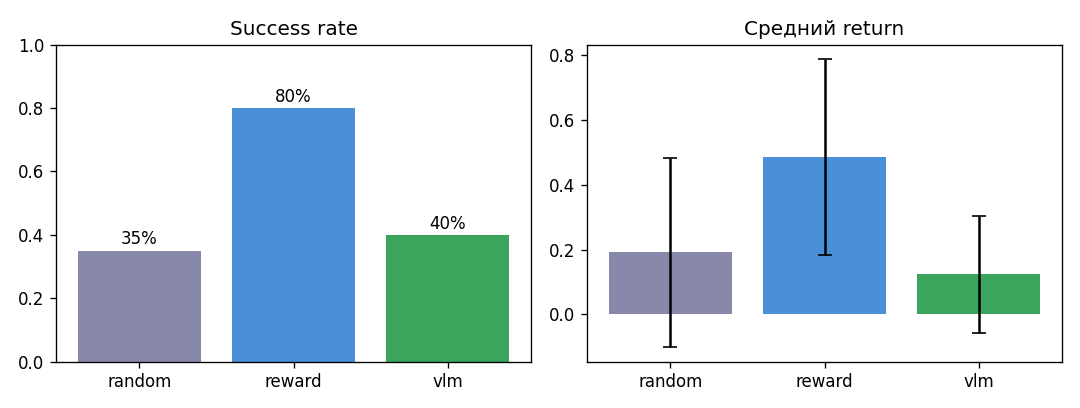

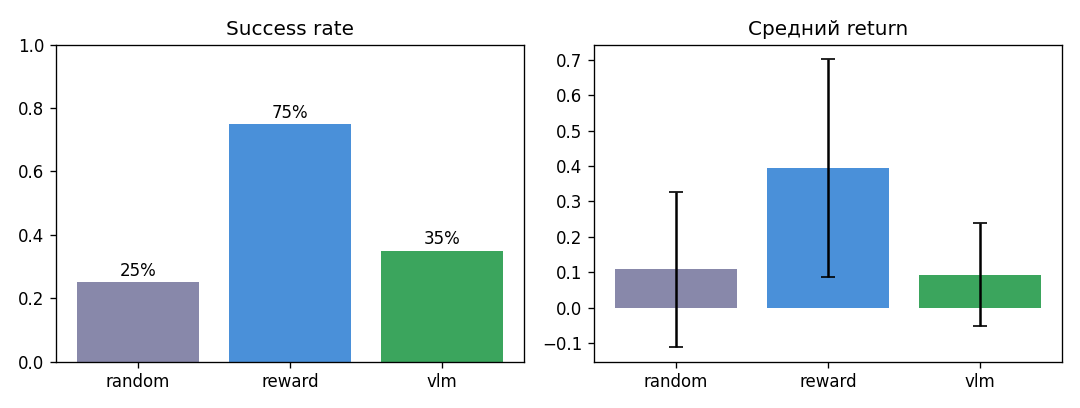

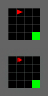

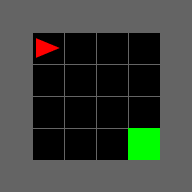

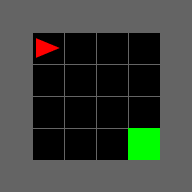

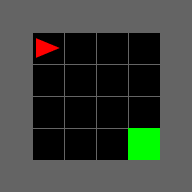

In [14]:
from IPython.display import Image, display
for tag, res in [('Empty-6x6', results6), ('Empty-8x8', results8)]:
    print('=====', tag, '=====')
    print_results(res)
display(Image('outputs/nb_6x6/results_bar.png'))
display(Image('outputs/nb_8x8/results_bar.png'))
display(Image('outputs/nb_6x6/imagined_vs_real.gif'))
for m in ('random', 'reward', 'vlm'):
    display(Image(f'outputs/nb_6x6/episode_{m}_0.gif'))

# Эксперимент 2. Что сломалось: декодер или CLIP?

Как только выяснилось, что CLIP не ведёт агента, первым делом захотелось понять — почему.
Вариантов два. Либо воображаемые кадры мутные, и виноват декодер модели мира. Либо CLIP сам по
себе плохо чувствует близость к цели, и качество кадра ни при чём. Развожу их так: отдельно
смотрю, насколько точно модель восстанавливает кадр, и отдельно — коррелирует ли оценка CLIP с
настоящим расстоянием до цели, причём и на живых кадрах среды, и на восстановленных. Если сигнал
есть на живых, но пропадает на восстановленных — виноват декодер; если его нет уже на живых —
виноват CLIP.

In [15]:
# диагностика: раскладываю провал VLM на два звена — декодер модели мира и сам CLIP
import sys, os

import numpy as np
import torch



def goal_pos(env):
    grid = env.unwrapped.grid
    for i in range(grid.width):
        for j in range(grid.height):
            c = grid.get(i, j)
            if c is not None and c.type == "goal":
                return np.array([i, j])
    return None


def spearman(a, b):
    ra = np.argsort(np.argsort(a)).astype(float)
    rb = np.argsort(np.argsort(b)).astype(float)
    ra = (ra - ra.mean()) / (ra.std() + 1e-8)
    rb = (rb - rb.mean()) / (rb.std() + 1e-8)
    return float((ra * rb).mean())


def collect(env_id, tile_size, n=150, seed=0):
    env = make_env(env_id, tile_size=tile_size, max_steps=64)
    rng = np.random.default_rng(seed)
    frames, dists = [], []
    ep = 0
    while len(frames) < n:
        obs, _ = env.reset(seed=int(seed * 1000 + ep)); ep += 1
        gp = goal_pos(env)
        done = False
        while not done and len(frames) < n:
            a = int(rng.choice([0, 1, 2], p=[0.2, 0.2, 0.6]))
            obs, r, term, trunc, _ = env.step(a)
            done = term or trunc
            ap = np.array(env.unwrapped.agent_pos)
            frames.append(obs_to_float(obs))
            dists.append(int(np.abs(ap - gp).sum()))
    env.close()
    return np.stack(frames), np.array(dists)


def wm_reconstruct(model, frames):
    """Прогоняем каждый кадр через encoder->posterior->decoder (1-шаговая реконструкция)."""
    device = next(model.parameters()).device
    recon = []
    with torch.no_grad():
        for i in range(0, len(frames), 64):
            batch = torch.from_numpy(frames[i:i + 64]).to(device)
            B = batch.shape[0]
            embeds = model.encoder(batch)
            h, z = model.init_state(B, device)
            zero_a = torch.zeros(B, model.num_actions, device=device)
            h, z, _, _ = model.posterior_step(h, z, zero_a, embeds)
            img = model.decoder(model._feat(h, z))
            recon.append(img.cpu())
    return torch.cat(recon, 0).numpy()


def main():
    cfg = Config()
    cfg.env_id = "MiniGrid-Empty-6x6-v0"
    cfg.image_size = 48
    # локально может лежать wm.pt; в чистом Colab обучается nb_wm_6x6.pt — берём что есть,
    # иначе диагностика молча падала бы на отсутствующем чекпоинте
    cfg.ckpt_path = next(
        (p for p in ("checkpoints/wm.pt", "checkpoints/nb_wm_6x6.pt") if os.path.exists(p)),
        "checkpoints/nb_wm_6x6.pt")
    device = resolve_device(cfg.device)
    print(f"device={device}, env={cfg.env_id}, ckpt={cfg.ckpt_path}")

    frames, dists = collect(cfg.env_id, cfg.tile_size, n=150, seed=0)
    target = -dists.astype(np.float32)
    print(f"кадров={len(frames)}, на цели (d=0): {(dists == 0).sum()}, "
          f"диапазон d=[{dists.min()},{dists.max()}]")

    scorer = CLIPScorer(cfg, device)
    model = load_world_model(cfg)

    real = frames
    recon = wm_reconstruct(model, frames)
    recon_err = float(np.mean((recon - real) ** 2))

    s_real = scorer.score(torch.from_numpy(real)).cpu().numpy()
    s_recon = scorer.score(torch.from_numpy(recon)).cpu().numpy()

    def report(name, s):
        rho = spearman(s, target)
        on = s[dists == 0].mean() if (dists == 0).any() else float("nan")
        off = s[dists >= 2].mean()
        print(f"  {name:16s} rho(скор,−dist)={rho:+.3f}  "
              f"скор[на цели]={on:.3f}  скор[d>=2]={off:.3f}  gap={on - off:+.3f}")

    print(f"\nреконструкция WM: MSE={recon_err:.4f}")
    print("CLIP-скор — способность отличать близость к цели:")
    report("реальные кадры", s_real)
    report("реконструкции WM", s_recon)

    print("\nВывод:")
    rr, rc = spearman(s_real, target), spearman(s_recon, target)
    if rr > 0.15 and rc < rr * 0.6:
        print("  сигнал есть на реальных кадрах, но ТЕРЯЕТСЯ на декодированных =>")
        print("  узкое место — размытость воображаемых кадров (декодер WM).")
    elif rr <= 0.15:
        print("  CLIP слабо различает даже РЕАЛЬНЫЕ кадры MiniGrid =>")
        print("  узкое место — сам сигнал VLM (домен рендера далёк от природных фото).")
    else:
        print("  сигнал переживает декодер; провал vlm скорее в агрегации/горизонте/шуме prior.")

In [16]:
# запускаю диагностику на модели 6x6, обученной в первом эксперименте
try:
    main()
except Exception as e:
    print('диагностика: пропущено —', e)

device=cuda, env=MiniGrid-Empty-6x6-v0, ckpt=checkpoints/nb_wm_6x6.pt
кадров=150, на цели (d=0): 5, диапазон d=[0,6]


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


реконструкция WM: MSE=0.0003
CLIP-скор — способность отличать близость к цели:
  реальные кадры   rho(скор,−dist)=+0.122  скор[на цели]=0.286  скор[d>=2]=0.293  gap=-0.007
  реконструкции WM rho(скор,−dist)=-0.209  скор[на цели]=0.310  скор[d>=2]=0.314  gap=-0.004

Вывод:
  CLIP слабо различает даже РЕАЛЬНЫЕ кадры MiniGrid ->
  узкое место — сам сигнал VLM (домен рендера далёк от природных фото).


# Расширенный анализ

Дальше — серия небольших разборов вокруг главного результата. Часть A про сам CLIP: карта оценки
по клеткам, попытка вытащить сигнал линейным слоем и сравнение двух версий модели. Часть B про
модель мира: докуда доверять воображению, что лежит в латентах и как откалибрована награда.
Часть C сравнивает случайный перебор с методом перекрёстной энтропии. Часть D щупает перенос на
DoorKey. Часть E проверяет, не выдаю ли я шум за результат. Все картинки складываются в
`outputs/analysis/`.

## Вспомогательные функции

Пара утилит для дальнейших разборов: подхватить обученную модель, набрать кадры с известным
расстоянием до цели, вытащить замороженные признаки CLIP, сжать их в 2D через SVD (специально без
внешней библиотеки — тут хватает `numpy`), плюс бутстрап и перестановочный тест для статистики.
Модель мира здесь везде берётся готовой, заново не учится.

In [17]:
import os, numpy as np, torch
from collections import defaultdict
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
os.makedirs('outputs/analysis', exist_ok=True)
ADEV = resolve_device('auto')
def _pick(*ps):
    for p in ps:
        if os.path.exists(p): return p
    return ps[0]
WM6 = ('MiniGrid-Empty-6x6-v0', 48, _pick('checkpoints/wm.pt','checkpoints/nb_wm_6x6.pt'))
WM8 = ('MiniGrid-Empty-8x8-v0', 64, _pick('checkpoints/wm_8x8.pt','checkpoints/nb_wm_8x8.pt'))

def load_wm(spec):
    env_id, imsize, ckpt = spec
    c = Config(); c.env_id=env_id; c.image_size=imsize; c.ckpt_path=ckpt
    return load_world_model(c), c

def a_goal_pos(env):
    g=env.unwrapped.grid
    for i in range(g.width):
        for j in range(g.height):
            cc=g.get(i,j)
            if cc is not None and cc.type=='goal': return np.array([i,j])
    return None

def a_spearman(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    ra=np.argsort(np.argsort(a)).astype(float); rb=np.argsort(np.argsort(b)).astype(float)
    ra=(ra-ra.mean())/(ra.std()+1e-8); rb=(rb-rb.mean())/(rb.std()+1e-8)
    return float((ra*rb).mean())

def collect_frames_with_dist(env_id, n=400, seed=0, tile_size=8, max_steps=64):
    env=make_env(env_id, tile_size=tile_size, max_steps=max_steps)
    rng=np.random.default_rng(seed); frames=[]; dists=[]; ep=0
    while len(frames)<n:
        obs,_=env.reset(seed=int(seed*1000+ep)); ep+=1
        gp=a_goal_pos(env); done=False
        while not done and len(frames)<n:
            a=int(rng.choice([0,1,2],p=[0.2,0.2,0.6]))
            obs,r,term,trunc,_=env.step(a); done=term or trunc
            ap=np.array(env.unwrapped.agent_pos)
            frames.append(obs_to_float(obs)); dists.append(int(np.abs(ap-gp).sum()))
    env.close()
    return np.stack(frames), np.array(dists)

def clip_features(scorer, frames, bs=128):
    outs=[]
    for i in range(0,len(frames),bs):
        b=torch.from_numpy(frames[i:i+bs]).to(scorer.device)
        outs.append(scorer._encode_images(b).cpu())
    return torch.cat(outs).numpy()

def pca2d(X):
    Xc=X-X.mean(0); U,S,Vt=np.linalg.svd(Xc, full_matrices=False)
    return Xc@Vt[:2].T

def bootstrap_ci(vals, stat=np.mean, n_boot=5000, seed=0, alpha=0.05):
    rng=np.random.default_rng(seed); vals=np.asarray(vals,float); n=len(vals)
    bs=np.array([stat(vals[rng.integers(0,n,n)]) for _ in range(n_boot)])
    lo,hi=np.quantile(bs,[alpha/2,1-alpha/2]); return float(stat(vals)),float(lo),float(hi)

def paired_permutation_test(a,b,n_perm=10000,seed=0):
    rng=np.random.default_rng(seed); d=np.asarray(a,float)-np.asarray(b,float); obs=d.mean(); cnt=0
    for _ in range(n_perm):
        s=rng.integers(0,2,len(d))*2-1
        if abs((d*s).mean())>=abs(obs): cnt+=1
    return float(obs), (cnt+1)/(n_perm+1)

print('хелперы анализа готовы; device =', ADEV)

хелперы анализа готовы; device = cuda


## A1. Куда CLIP «смотрит»: карта оценки по клеткам

Если оценкой CLIP можно планировать, она обязана расти к цели и достигать максимума на клетке
цели. Проверяю в лоб: сажаю агента по очереди в каждую свободную клетку (усредняя по четырём
направлениям), рендерю кадр и скорю. Получается тепловая карта оценки по позиции агента.

Забегая вперёд — карта выходит почти плоской, и её максимум сидит не на цели. То есть без
дообучения CLIP просто не выделяет «агент дошёл», и планировать по такой оценке фактически
нечем.

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

6x6: пик скора в (np.int64(3), np.int64(1)), цель в (np.int64(4), np.int64(4)) -> совпадают: False
saved: outputs/analysis/clip_heatmap_6x6.png


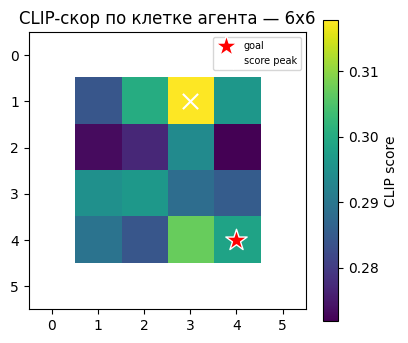

8x8: пик скора в (np.int64(4), np.int64(6)), цель в (np.int64(6), np.int64(6)) -> совпадают: False
saved: outputs/analysis/clip_heatmap_8x8.png


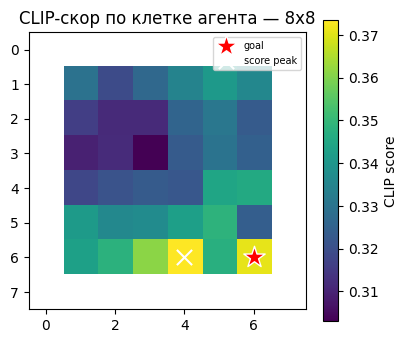

In [35]:
%matplotlib inline

from IPython.display import display
import os

scorer = CLIPScorer(Config(), ADEV)

def clip_heatmap(spec, tag, show=True):
    env_id, imsize, _ = spec
    env = make_env(env_id, tile_size=8)
    env.reset(seed=0)
    u = env.unwrapped
    W, H = u.grid.width, u.grid.height
    gp = a_goal_pos(env)
    frames = []
    cells = []
    for x in range(W):
        for y in range(H):
            c = u.grid.get(x, y)
            if c is not None and c.type == 'wall':
                continue

            for d in range(4):
                u.agent_pos = (x, y)
                u.agent_dir = d

                frames.append(
                    obs_to_float(
                        u.get_frame(highlight=False, tile_size=8)
                    )
                )
                cells.append((x, y))

    env.close()
    s = scorer.score(torch.from_numpy(np.stack(frames))).cpu().numpy()
    acc = defaultdict(list)
    for (x, y), sv in zip(cells, s):
        acc[(x, y)].append(float(sv))
    grid = np.full((H, W), np.nan)
    for (x, y), vs in acc.items():
        grid[y, x] = np.mean(vs)

    peak = np.unravel_index(np.nanargmax(grid), grid.shape)
    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    im = ax.imshow(grid, cmap='viridis')
    fig.colorbar(im, ax=ax, label='CLIP score')
    ax.scatter(
        [gp[0]],
        [gp[1]],
        marker='*',
        s=260,
        c='red',
        edgecolors='white',
        label='goal'
    )

    ax.scatter(
        [peak[1]],
        [peak[0]],
        marker='x',
        s=120,
        c='white',
        label='score peak'
    )

    ax.legend(loc='upper right', fontsize=7)
    ax.set_title(f'CLIP-скор по клетке агента — {tag}')
    fig.tight_layout()
    os.makedirs('outputs/analysis', exist_ok=True)
    p = f'outputs/analysis/clip_heatmap_{tag}.png'
    fig.savefig(p, dpi=120)
    print(
        f'{tag}: пик скора в {peak[::-1]}, цель в {tuple(gp)} '
        f'-> совпадают: {tuple(peak[::-1]) == tuple(gp)}'
    )
    print('saved:', p)
    if show:
        display(fig)
    plt.close(fig)
    return p


p6 = clip_heatmap(WM6, '6x6')
try:
    p8 = clip_heatmap(WM8, '8x8')
except Exception as e:
    print('8x8 heatmap skipped:', e)

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
!cp -r checkpoints /content/drive/MyDrive/
!cp -r data /content/drive/MyDrive/
!cp -r outputs /content/drive/MyDrive/

## A3. Может, дело в версии CLIP?

Логично было предположить, что модель побольше почувствует цель лучше. Сравниваю B/32 и B/16 по
ранговой корреляции оценки с близостью к цели на живых кадрах.

Корреляция у обеих болтается около нуля и даже знак меняет от выборки к выборке; крупная версия
не спасает. Значит, проблема не в размере, а в домене: аккуратные «векторные» рендеры MiniGrid
слишком далеки от фотографий, на которых CLIP росла.

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

модель                     rho  near-far
clip-vit-base-patch32   -0.188   -0.0173
clip-vit-base-patch16   -0.420   -0.0432


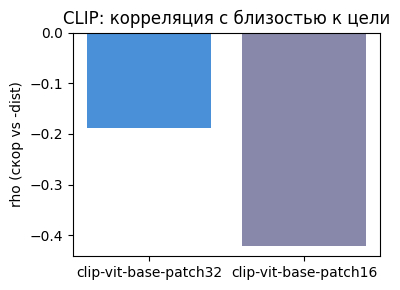

[('clip-vit-base-patch32', -0.18752517635085358, -0.01726776361465454),
 ('clip-vit-base-patch16', -0.42023597165908844, -0.04322785139083862)]

In [36]:
from IPython.display import display
import os

def compare_clip(models=('openai/clip-vit-base-patch32','openai/clip-vit-base-patch16')):
    frames,dists=collect_frames_with_dist('MiniGrid-Empty-6x6-v0', n=250, seed=1)
    tgt=-dists.astype(float); rows=[]
    for m in models:
        try:
            c=Config(); c.clip_model=m; sc=CLIPScorer(c,ADEV)
            s=sc.score(torch.from_numpy(frames)).cpu().numpy()
            near=s[dists<=1].mean() if (dists<=1).any() else float('nan')
            far=s[dists>=3].mean() if (dists>=3).any() else float('nan')
            rows.append((m.split('/')[-1], a_spearman(s,tgt), float(near-far)))
            del sc
        except Exception as e:
            print('skip', m, e)
    print(f"{'модель':22s} {'rho':>7} {'near-far':>9}")
    for n,rho,gap in rows: print(f'{n:22s} {rho:7.3f} {gap:9.4f}')
    if rows:
        os.makedirs('outputs/analysis',exist_ok=True)
        plt.figure(figsize=(4,3)); plt.bar([r[0] for r in rows],[r[1] for r in rows],color=['#4a90d9','#8888aa'])
        plt.ylabel('rho (скор vs -dist)'); plt.title('CLIP: корреляция с близостью к цели'); plt.axhline(0,c='k',lw=.5)
        plt.tight_layout(); plt.savefig('outputs/analysis/vlm_compare.png',dpi=120); display(plt.gcf()); plt.close()
    return rows

compare_clip()

## B1. Насколько далеко можно верить воображению

Ошибка модели мира копится с каждым шагом развёртки, так что дальний горизонт — это уже
фантазия, и это ограничивает разумный H. Меряю прямо: из первого кадра раскручиваю развёртку по
настоящим действиям и на каждом шаге смотрю, насколько воображаемый кадр разошёлся с реальным.
Ошибка ожидаемо растёт — вот примерно там и проходит граница, до которой воображению можно
доверять.

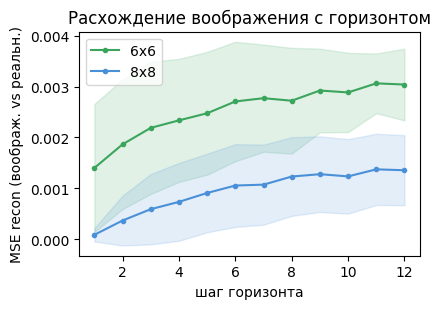

divergence: ok


In [37]:
DATA={'6x6':_pick('data/rollouts.npz','data/nb_6x6.npz'), '8x8':_pick('data/rollouts_8x8.npz','data/nb_8x8.npz')}
def imagination_divergence(spec, tag, H=12, K=40):
    model,c=load_wm(spec); data=load_data(DATA[tag]); dev=next(model.parameters()).device
    eps=[i for i in range(len(data['act'])) if len(data['act'][i])>=H]
    rng=np.random.default_rng(0); sel=rng.choice(eps, min(K,len(eps)), replace=False)
    errs=[]
    for i in sel:
        obs=data['obs'][i]; act=data['act'][i]
        h,z=model.state_from_obs(torch.from_numpy(obs[0:1]), torch.zeros(0,dtype=torch.long))
        at=torch.tensor(act[:H],dtype=torch.long, device=dev).unsqueeze(0)
        frames,_=model.imagine(h,z,at,decode='all'); imagined=frames[0].cpu().numpy()
        real=obs[1:H+1]; m=min(len(imagined),len(real))
        errs.append([float(((imagined[t]-real[t])**2).mean()) for t in range(m)])
    L=min(len(e) for e in errs); arr=np.array([e[:L] for e in errs])
    return arr.mean(0), arr.std(0)
plt.figure(figsize=(4.4,3.2))
for spec,tag,col in [(WM6,'6x6','#3ba55d'),(WM8,'8x8','#4a90d9')]:
    try:
        mean,std=imagination_divergence(spec,tag)
        xs=np.arange(1,len(mean)+1); plt.plot(xs,mean,marker='o',ms=3,c=col,label=tag)
        plt.fill_between(xs,mean-std,mean+std,color=col,alpha=0.15)
    except Exception as e: print(tag,'skipped:',e)
plt.xlabel('шаг горизонта'); plt.ylabel('MSE recon (воображ. vs реальн.)')
plt.title('Расхождение воображения с горизонтом'); plt.legend(); plt.tight_layout()
os.makedirs('outputs/analysis',exist_ok=True)
plt.savefig('outputs/analysis/imagination_divergence.png',dpi=120); display(plt.gcf()); plt.close(); print('divergence: ok')


## B2. Что выучила модель мира: латентное пространство

Если модель мира и правда полезна, её латентное состояние должно как-то кодировать геометрию
задачи — хотя бы близость к цели. Прогоняю кадры через апостериор, проецирую состояния в 2D через
SVD и крашу точки по расстоянию до цели. На графике ниже точки раскладываются по расстоянию
довольно упорядоченно — то есть геометрия в латентах действительно есть. Это, кстати, косвенно
объясняет, почему планирование по награде так надёжно.

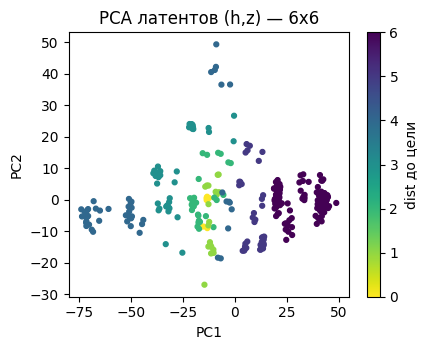

6x6 latent PCA ok


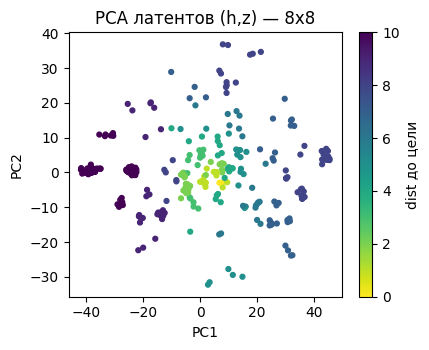

8x8 latent PCA ok


In [38]:
def latent_pca(spec, tag, n=300):
    model,c=load_wm(spec); dev=next(model.parameters()).device
    frames,dists=collect_frames_with_dist(spec[0], n=n, seed=2)
    feats=[]
    with torch.no_grad():
        for i in range(0,len(frames),64):
            b=torch.from_numpy(frames[i:i+64]).to(dev); B=b.shape[0]
            emb=model.encoder(b); h,z=model.init_state(B,dev); zero=torch.zeros(B,model.num_actions,device=dev)
            h,z,_,_=model.posterior_step(h,z,zero,emb); feats.append(model._feat(h,z).cpu().numpy())
    X=np.concatenate(feats); P=pca2d(X)
    plt.figure(figsize=(4.4,3.6)); sc=plt.scatter(P[:,0],P[:,1],c=dists,cmap='viridis_r',s=12)
    plt.colorbar(sc,label='dist до цели'); plt.title(f'PCA латентов (h,z) — {tag}')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.tight_layout()
    os.makedirs('outputs/analysis',exist_ok=True)
    p=f'outputs/analysis/latent_pca_{tag}.png'; plt.savefig(p,dpi=120); display(plt.gcf()); plt.close(); print(tag,'latent PCA ok'); return p

latent_pca(WM6,'6x6')
try:
  latent_pca(WM8,'8x8')
except Exception as e:
  print('8x8 latents skipped:',e)

## B3. Почему награда работает так надёжно: калибровка

Планирование по награде уверенно доходит до цели, и хочется связать это с качеством головы
награды. Проверяю, сравнивая предсказанную награду с настоящей на реальных последовательностях
(само число — в выводе ячейки ниже). Корреляция получается вполне заметной, несмотря на
разреженность награды, — отсюда и устойчивый «наклон» всего планирования в сторону цели.

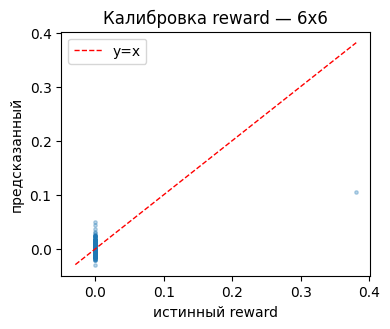

6x6: corr(pred,true)=0.381


In [39]:
def reward_calibration(spec, tag, seq_len=16, batch=64):
    model,c=load_wm(spec); data=load_data(DATA[tag]); dev=next(model.parameters()).device
    sampler=SequenceSampler(data, seq_len=seq_len, seed=0)
    obs,act,rew=sampler.sample(batch)
    with torch.no_grad():
        out=model.observe(torch.from_numpy(obs).to(dev), torch.from_numpy(act).to(dev))
    rp=out['reward_pred'][:,1:].cpu().numpy(); rt=rew
    m=min(rp.shape[1],rt.shape[1]); pred=rp[:,:m].ravel(); true=rt[:,:m].ravel()
    plt.figure(figsize=(4,3.4)); plt.scatter(true,pred,s=6,alpha=0.3)
    lim=[min(true.min(),pred.min()),max(true.max(),pred.max())]; plt.plot(lim,lim,'r--',lw=1,label='y=x')
    plt.xlabel('истинный reward'); plt.ylabel('предсказанный'); plt.title(f'Калибровка reward — {tag}')
    plt.legend(); plt.tight_layout(); os.makedirs('outputs/analysis',exist_ok=True)
    p=f'outputs/analysis/reward_calibration_{tag}.png'; plt.savefig(p,dpi=120); display(plt.gcf()); plt.close()
    print(f'{tag}: corr(pred,true)={np.corrcoef(pred,true)[0,1]:.3f}'); return p

try:
  reward_calibration(WM6,'6x6')
except Exception as e:
  print('reward calib skipped:',e)


## C. Поиск действий: случайный перебор против перекрёстной энтропии

Метод перекрёстной энтропии заявлен как необязательный бонус, и мне показалось нечестным
оставлять его только в коде — так что вот он в деле. Сравниваю два поиска на одной модели мира,
целясь в предсказанную награду: так разница зависит только от качества поиска и не тащит за собой
шум CLIP. Смотрю не только на успех, но и на цену — число обращений к цели на шаг: это N у
случайного перебора и N×(число итераций) у перекрёстной энтропии.

случайный перебор     : доля успехов=67% награда=0.424 обращений к цели на шаг=48
перекрёстная энтропия : доля успехов=87% награда=0.665 обращений к цели на шаг=144


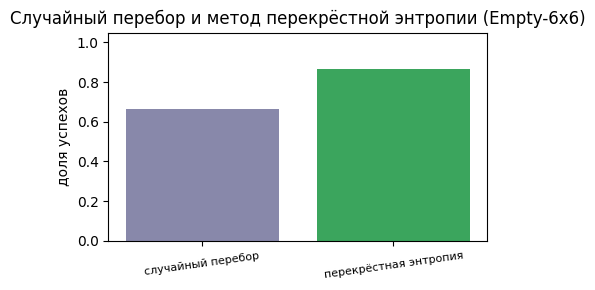

In [40]:
from dataclasses import replace as _replace

_cfgc = Config(); _cfgc.env_id='MiniGrid-Empty-6x6-v0'; _cfgc.image_size=48
_cfgc.ckpt_path=_pick('checkpoints/wm.pt','checkpoints/nb_wm_6x6.pt')
_cfgc.horizon=10; _cfgc.n_candidates=48; _cfgc.max_steps=64
model_c = load_world_model(_cfgc)
rows=[]

for name, iters in [('случайный перебор',0), ('перекрёстная энтропия',3)]:
    cfgi=_replace(_cfgc, cem_iterations=iters, cem_elites=8, eval_seeds=tuple(range(15)))
    r=evaluate_method(name, lambda s,c=cfgi: make_agent('reward', model_c, c, seed=s), cfgi, cfgi.eval_seeds, record_first=0)
    evals=_cfgc.n_candidates*(iters if iters>0 else 1)
    rows.append((name, r['success_rate'], evals))
    print(f"{name:22s}: доля успехов={r['success_rate']:.0%} награда={r['return_mean']:.3f} обращений к цели на шаг={evals}")

plt.figure(figsize=(4.6,3)); plt.bar([x[0] for x in rows],[x[1] for x in rows],color=['#8888aa','#3ba55d'])
plt.ylabel('доля успехов'); plt.ylim(0,1.05); plt.xticks(rotation=8,fontsize=8)
plt.title('Случайный перебор и метод перекрёстной энтропии (Empty-6x6)'); plt.tight_layout()
os.makedirs('outputs/analysis',exist_ok=True)
plt.savefig('outputs/analysis/planner_cem.png',dpi=120); display(plt.gcf()); plt.close()

## D. Тянется ли идея на многошаговый DoorKey

В DoorKey цель составная: сначала ключ, потом дверь, и только потом выход. Напрашивается вести
агента по цепочке промежуточных описаний. Но прежде чем городить это целиком, я проверила на
живых кадрах DoorKey самое базовое — различает ли вообще CLIP фазы эпизода (есть ключ / дверь
открыта), которые я определяю по состоянию среды. Модель мира тут не учу, это чистый тест
восприятия.

Под случайной политикой всплывают только две фазы — до ключа и с ключом; дверь за 120 эпизодов
не открывается ни разу, а оценки CLIP фазы почти не разделяют. Вывод двойной: для многошаговых
задач нужен направленный сбор данных, и слабость CLIP из пустой комнаты честно переезжает и
сюда.

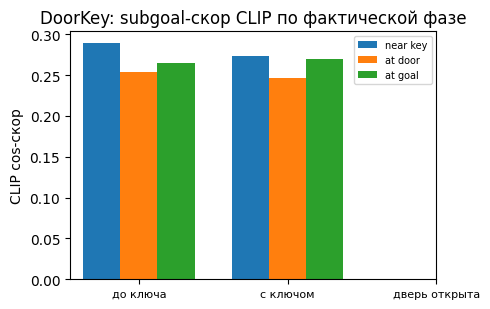

DoorKey фазы (кадров): {0: 129, 1: 171, 2: 0}


In [41]:
def door_open(u):
    g=u.grid
    for i in range(g.width):
        for j in range(g.height):
            cc=g.get(i,j)
            if cc is not None and cc.type=='door': return bool(getattr(cc,'is_open',False))
    return False
def doorkey_subgoals(n=300):
    env=make_env('MiniGrid-DoorKey-6x6-v0', tile_size=8, max_steps=128)
    rng=np.random.default_rng(0); frames=[]; phases=[]
    for ep in range(120):
        obs,_=env.reset(seed=ep); u=env.unwrapped; done=False; steps=0
        while not done and steps<128:
            a=int(rng.integers(0,env.action_space.n)); obs,r,term,trunc,_=env.step(a); done=term or trunc; steps+=1
            has_key=u.carrying is not None and getattr(u.carrying,'type','')=='key'
            ph=2 if door_open(u) else (1 if has_key else 0)
            frames.append(obs_to_float(obs)); phases.append(ph)
            if len(frames)>=n: break
        if len(frames)>=n: break
    env.close(); return np.stack(frames), np.array(phases)
frames,phases=doorkey_subgoals()
prompts={'near key':'a red triangle agent next to a yellow key',
         'at door':'a red triangle agent at an open door',
         'at goal':'a red triangle on a green goal square'}
emb=clip_features(scorer, frames)
names=['до ключа','с ключом','дверь открыта']
import numpy as _np
plt.figure(figsize=(5,3.2)); width=0.25
for k,(lab,pr) in enumerate(prompts.items()):
    te=scorer._encode_text([pr]).cpu().numpy()[0]; s=emb@te
    means=[float(s[phases==ph].mean()) if (phases==ph).any() else _np.nan for ph in (0,1,2)]
    xs=_np.arange(3)+k*width; plt.bar(xs,means,width=width,label=lab)
plt.xticks(_np.arange(3)+width,names,fontsize=8); plt.ylabel('CLIP cos-скор'); plt.legend(fontsize=7)
plt.title('DoorKey: subgoal-скор CLIP по фактической фазе'); plt.tight_layout()
os.makedirs('outputs/analysis',exist_ok=True)
plt.savefig('outputs/analysis/doorkey_subgoal_scores.png',dpi=120); display(plt.gcf()); plt.close()
print('DoorKey фазы (кадров):', {int(p):int((phases==p).sum()) for p in (0,1,2)})

## E. Насколько выводам можно верить

20 эпизодов на метод — всё ещё немного, поэтому стоит спросить, не шум ли это. Строю
бутстрап-интервалы уровня 0.95 для доли успехов и парные перестановочные тесты между методами на
общих seed'ах. Данные беру прямо из результатов первого эксперимента, посчитанных выше в этом же
ноутбуке.

Ожидаю увидеть, что на 6x6 преимущество награды над CLIP значимо, а на 8x8 значимость уже пляшет
от числа эпизодов. Заодно печатаю цену метода: сколько обращений к CLIP уходит на шаг при разных
способах агрегирования — либо N, либо N×H.

Empty-6x6: reward и vlm p=0.020 | reward и random p=0.011
Empty-8x8: reward и vlm p=0.039 | reward и random p=0.006


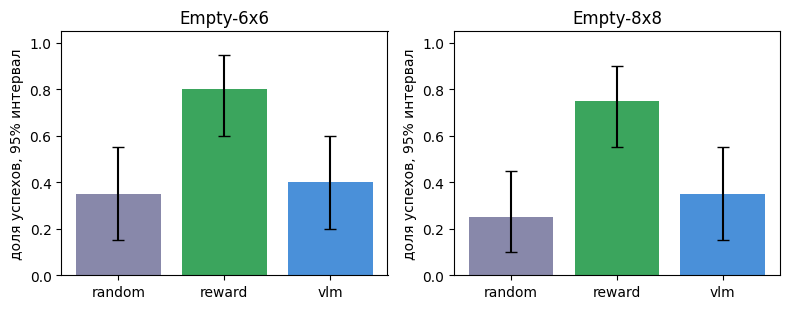

агрегирование last      : обращений к CLIP на шаг = N  (N — число кандидатов, H — горизонт)
агрегирование last_max  : обращений к CLIP на шаг = N*H  (N — число кандидатов, H — горизонт)
агрегирование sum       : обращений к CLIP на шаг = N*H  (N — число кандидатов, H — горизонт)
агрегирование discounted: обращений к CLIP на шаг = N*H  (N — число кандидатов, H — горизонт)


In [42]:
def _mm(results):
  return {r['method']:r for r in results}

def stats_panel():
    data=[('Empty-6x6', results6), ('Empty-8x8', results8)]
    fig,axes=plt.subplots(1,2,figsize=(8,3.2),squeeze=False); axes=axes[0]
    for ax,(tag,res) in zip(axes,data):
        R=_mm(res); methods=[m for m in ('random','reward','vlm') if m in R]; xs=np.arange(len(methods))
        succ=[]; los=[]; his=[]
        for m in methods:
            sr,lo,hi=bootstrap_ci([int(x) for x in R[m]['successes']]); succ.append(sr); los.append(sr-lo); his.append(hi-sr)
        ax.bar(xs,succ,yerr=[los,his],capsize=4,color=['#8888aa','#3ba55d','#4a90d9'][:len(methods)])
        ax.set_xticks(xs); ax.set_xticklabels(methods); ax.set_ylim(0,1.05); ax.set_title(tag); ax.set_ylabel('доля успехов, 95% интервал')
        rv=[int(x) for x in R['reward']['successes']]; vv=[int(x) for x in R['vlm']['successes']]; nv=[int(x) for x in R['random']['successes']]
        _,p_rv=paired_permutation_test(rv,vv); _,p_rn=paired_permutation_test(rv,nv)
        print(f'{tag}: reward и vlm p={p_rv:.3f} | reward и random p={p_rn:.3f}')
    plt.tight_layout(); os.makedirs('outputs/analysis',exist_ok=True); plt.savefig('outputs/analysis/stats_ci.png',dpi=120); display(fig); plt.close()
stats_panel()

for agg,calls in [('last','N'),('last_max','N*H'),('sum','N*H'),('discounted','N*H')]:
    print(f'агрегирование {agg:10s}: обращений к CLIP на шаг = {calls}  (N — число кандидатов, H — горизонт)')

## A2. А есть ли вообще сигнал в признаках CLIP: линейный пробинг

Для меня это самый важный эксперимент. Оценка «из коробки» не работает — но, может, информация о
близости к цели в признаках CLIP всё-таки есть, просто её не вытащить голым косинусом.

Проверяю так: замораживаю CLIP и учу поверх её признаков $\psi(o)$ один логистический слой,
предсказывающий «агент близко к цели» (расстояние $\le 1$):

$$\hat y=\sigma\big(w^\top\psi(o)+b\big),\qquad
\mathcal L=\mathrm{BCE}(\hat y,y)+\lambda\lVert w\rVert^2.$$

Потом заворачиваю обученный слой в тот же интерфейс, что и CLIP-оценщик, и подставляю в
неизменный планировщик. Конкретные числа — в выводе ячеек ниже, но картина такая: на отложенной
выборке корреляция с близостью подскакивает с почти нуля до вполне рабочей, а в планировании
(единый протокол: одна модель мира, общие seed'ы) пробинг уверенно обгоняет и zero-shot CLIP, и
случайного агента — хотя до планирования по награде всё равно не дотягивает.

Мне это кажется главным итогом: провал CLIP — не приговор. Информация в признаках есть, её
вытаскивает даже один линейный слой. Остаточный разрыв с наградой списываю на две вещи —
классификатор учился на живых кадрах, а планировщик скорит восстановленные (несовпадение
доменов), плюс маленькая выборка.

zero-shot CLIP rho=-0.023 | probe rho=+0.646 | probe val-acc=0.95


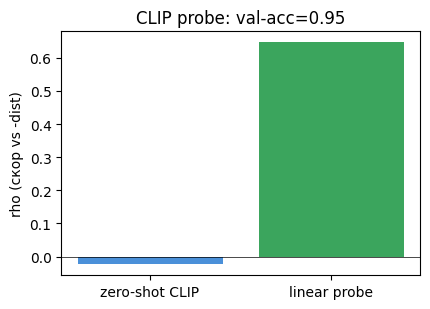

In [43]:
# данные и признаки
ftr,dtr=collect_frames_with_dist('MiniGrid-Empty-6x6-v0', n=800, seed=0)
fva,dva=collect_frames_with_dist('MiniGrid-Empty-6x6-v0', n=400, seed=7)
Xtr=clip_features(scorer,ftr); Xva=clip_features(scorer,fva)
ytr=(dtr<=1).astype(np.float32); yva=(dva<=1).astype(np.float32)
# обучение линейного классификатора
Xt=torch.tensor(Xtr,device=ADEV); yt=torch.tensor(ytr,device=ADEV)
W=torch.zeros(Xt.shape[1],device=ADEV,requires_grad=True); b=torch.zeros(1,device=ADEV,requires_grad=True)
opt=torch.optim.Adam([W,b],lr=0.05)
for step in range(400):
    opt.zero_grad(); logit=Xt@W+b; loss=torch.nn.functional.binary_cross_entropy_with_logits(logit,yt)+1e-3*W.pow(2).sum()
    loss.backward(); opt.step()
Wn=W.detach().cpu().numpy(); bn=float(b.detach().cpu().numpy()[0])
# прирост сигнала на отложенной выборке
pv=1/(1+np.exp(-(Xva@Wn+bn)))
zs=scorer.score(torch.from_numpy(fva)).cpu().numpy()  # без дообучения
rho_probe=a_spearman(pv,-dva.astype(float)); rho_zs=a_spearman(zs,-dva.astype(float))
acc=float(((pv>0.5).astype(float)==yva).mean())
print(f'zero-shot CLIP rho={rho_zs:+.3f} | probe rho={rho_probe:+.3f} | probe val-acc={acc:.2f}')
os.makedirs('outputs/analysis',exist_ok=True)
np.savez('outputs/analysis/clip_probe.npz', W=Wn, b=bn, clip_model='openai/clip-vit-base-patch32')

plt.figure(figsize=(4.4,3.2)); plt.bar(['zero-shot CLIP','linear probe'],[rho_zs,rho_probe],color=['#4a90d9','#3ba55d'])
plt.ylabel('rho (скор vs -dist)'); plt.title(f'CLIP probe: val-acc={acc:.2f}'); plt.axhline(0,c='k',lw=.5)
plt.tight_layout(); plt.savefig('outputs/analysis/clip_probe.png',dpi=120); display(plt.gcf()); plt.close()

random          : success=40% return=0.290
reward          : success=100% return=0.780
vlm (zero-shot) : success=30% return=0.202
vlm+probe       : success=50% return=0.238


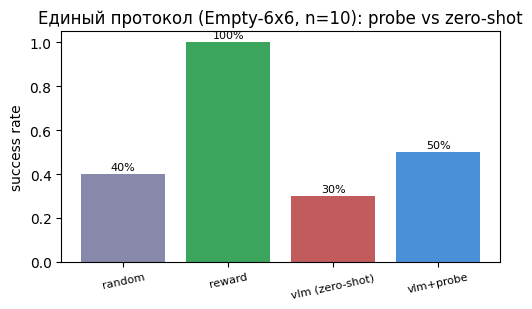

probe_rescue.png saved


In [44]:
# оборачиваем классификатор в интерфейс оценщика CLIP, планировщик не меняем
class ProbeScorer:
    def __init__(self, clip_scorer, W, b):
        self.clip=clip_scorer; self.device=clip_scorer.device
        self.W=torch.tensor(W,dtype=torch.float32,device=self.device); self.b=float(b)
    @torch.no_grad()
    def score(self, frames):
        emb=self.clip._encode_images(frames.to(self.device)); return torch.sigmoid(emb@self.W+self.b)
probe_scorer=ProbeScorer(scorer,Wn,bn)

# честное сравнение всех методов при едином протоколе: одна модель мира, одни начальные значения, один предел шагов
cfg6=Config(); cfg6.env_id='MiniGrid-Empty-6x6-v0'; cfg6.image_size=48; cfg6.ckpt_path=_pick('checkpoints/wm.pt','checkpoints/nb_wm_6x6.pt')
cfg6.horizon=10; cfg6.n_candidates=48; cfg6.vlm_aggregate='last'; cfg6.max_steps=96; cfg6.eval_seeds=tuple(range(10))
model6=load_world_model(cfg6)
agents={
    'random':          lambda s: make_agent('random', model6, cfg6, seed=s),
    'reward':          lambda s: make_agent('reward', model6, cfg6, seed=s),
    'vlm (zero-shot)': lambda s: make_agent('vlm', model6, cfg6, scorer=scorer, seed=s),
    'vlm+probe':       lambda s: make_agent('vlm', model6, cfg6, scorer=probe_scorer, seed=s),
}
succ={}; ret={}
for name,mk in agents.items():
    r=evaluate_method(name, mk, cfg6, cfg6.eval_seeds, record_first=0)
    succ[name]=r['success_rate']; ret[name]=r['return_mean']
    print(f'{name:16s}: success={r["success_rate"]:.0%} return={r["return_mean"]:.3f}')
labels=list(succ); vals=[succ[k] for k in labels]
plt.figure(figsize=(5.2,3.2)); plt.bar(labels,vals,color=['#8888aa','#3ba55d','#c25b5b','#4a90d9'])
plt.ylabel('success rate'); plt.ylim(0,1.05); plt.xticks(rotation=12,fontsize=8)
for i,v in enumerate(vals): plt.text(i,v+0.02,f'{v:.0%}',ha='center',fontsize=8)
plt.title('Единый протокол (Empty-6x6, n=10): probe vs zero-shot'); plt.tight_layout()
os.makedirs('outputs/analysis',exist_ok=True)
plt.savefig('outputs/analysis/probe_rescue.png',dpi=120); display(plt.gcf()); plt.close(); print('probe_rescue.png saved')


# H1. Где учить probe: на реальных кадрах или на восстановленных моделью мира?

{'zero-shot CLIP': -0.221, 'probe на реальных': 0.521, 'probe на восстановл.': 0.5}


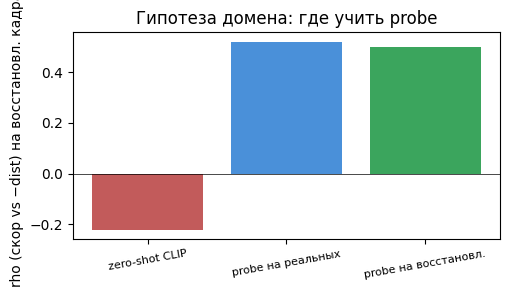

In [45]:
%matplotlib inline
from IPython.display import display
import os

# H1. Где учить probe: на реальных кадрах или на восстановленных моделью мира?
import numpy as np, torch, matplotlib.pyplot as plt

wm6, _ = load_wm(WM6)  # обученная модель мира 6x6
fr_tr, d_tr = collect_frames_with_dist('MiniGrid-Empty-6x6-v0', n=800, seed=0)
fr_va, d_va = collect_frames_with_dist('MiniGrid-Empty-6x6-v0', n=400, seed=7)
rec_tr = wm_reconstruct(wm6, fr_tr)  # те же кадры через encoder-decoder
rec_va = wm_reconstruct(wm6, fr_va)

def fit_probe(frames, dists):
    X = torch.tensor(clip_features(scorer, frames), device=ADEV)
    y = torch.tensor((dists <= 1).astype(np.float32), device=ADEV)
    W = torch.zeros(X.shape[1], device=ADEV, requires_grad=True)
    b = torch.zeros(1, device=ADEV, requires_grad=True)
    opt = torch.optim.Adam([W, b], lr=0.05)
    for _ in range(400):
        opt.zero_grad()
        loss = torch.nn.functional.binary_cross_entropy_with_logits(X@W+b, y) + 1e-3*W.pow(2).sum()
        loss.backward(); opt.step()
    return W.detach().cpu().numpy(), float(b.detach().cpu().numpy()[0])

def rho_on(frames, W, b, dists):
    p = 1/(1+np.exp(-(clip_features(scorer, frames)@W + b)))
    return a_spearman(p, -dists.astype(float))

Wr, br = fit_probe(fr_tr,  d_tr) # на реальных
Wc, bc = fit_probe(rec_tr, d_tr)  # на восстановленных
zs   = a_spearman(scorer.score(torch.from_numpy(rec_va)).cpu().numpy(), -d_va.astype(float))
labels = ['zero-shot CLIP', 'probe на реальных', 'probe на восстановл.']
vals   = [zs, rho_on(rec_va, Wr, br, d_va), rho_on(rec_va, Wc, bc, d_va)]
print({k: round(v, 3) for k, v in zip(labels, vals)})
plt.figure(figsize=(5.2,3)); plt.bar(labels, vals, color=['#c25b5b','#4a90d9','#3ba55d'])
plt.axhline(0, c='k', lw=.5); plt.ylabel('rho (скор vs −dist) на восстановл. кадрах')
plt.title('Гипотеза домена: где учить probe'); plt.xticks(rotation=10, fontsize=8)
plt.tight_layout(); os.makedirs('outputs/analysis',exist_ok=True); plt.savefig('outputs/analysis/probe_domain.png', dpi=120); display(plt.gcf()); plt.close()

# H3. Гипотеза про промпт: сигнал сильно зависит от формулировки

-0.262  red triangle on green square
-0.286  triangle next to green
-0.362  agent reached the goal
+0.230  game completed


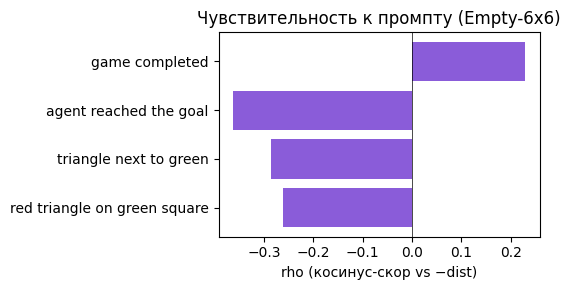

In [46]:
import torch, matplotlib.pyplot as plt

frames, dists = collect_frames_with_dist('MiniGrid-Empty-6x6-v0', n=300, seed=3)
emb = clip_features(scorer, frames)
prompts = {
    'red triangle on green square': 'a red triangle on top of a green square',
    'triangle next to green':       'a red triangle next to a green square',
    'agent reached the goal':       'an agent that reached the goal',
    'game completed':               'a completed maze game',
}
rows = [(name, a_spearman(emb @ scorer._encode_text([p]).cpu().numpy()[0], -dists.astype(float)))
        for name, p in prompts.items()]
for n, v in rows: print(f'{v:+.3f}  {n}')
plt.figure(figsize=(5.6,3)); plt.barh([r[0] for r in rows], [r[1] for r in rows], color='#8a5cd9')
plt.axvline(0, c='k', lw=.5); plt.xlabel('rho (косинус-скор vs −dist)')
plt.title('Чувствительность к промпту (Empty-6x6)'); plt.tight_layout()
os.makedirs('outputs/analysis',exist_ok=True)
plt.savefig('outputs/analysis/prompt_sensitivity.png', dpi=120); display(plt.gcf()); plt.close()

# Выводы
## Что реализовано
В проекте реализован demo-pipeline, который объединяет learned world model и VLM-based scorer для управления агентом в MiniGrid. В качестве сред использовались MiniGrid-Empty-6x6-v0 и MiniGrid-Empty-8x8-v0, где цель — дойти до зелёной goal-клетки.

Наблюдением был полный RGB-рендер всей сетки, а не стандартное частичное MiniGrid-наблюдение. Это нужно, чтобы world model и CLIP работали с визуальным представлением одного типа.

В качестве world model реализована компактная RSSM-модель в стиле PlaNet/Dreamer. Она кодирует кадры, поддерживает латентное рекуррентное состояние и умеет делать imagined rollouts на горизонте H без обращения к среде. По этим rollout-ам модель декодирует будущие кадры и предсказывает reward.

Планирование сделано через MPC/random shooting: на каждом шаге генерируются несколько последовательностей действий, они прогоняются через world model, оцениваются, после чего агент выполняет первое действие лучшей последовательности.

Сравнивались три метода:

random policy;
world-model planning без VLM, где objective — predicted reward;
world-model planning + CLIP score на imagined future frames.


## Гипотезы и их проверка
1. **World model можно обучить достаточно хорошо для imagined rollouts**

Эта гипотеза в целом подтвердилась. RSSM научилась достаточно хорошо реконструировать кадры и предсказывать короткие rollouts. Ошибка растёт с горизонтом, но на H=10–12 модель ещё пригодна для MPC.

Главное подтверждение — planning по predicted reward. Агент с этим objective сильно превосходит random baseline и часто доходит до goal.

2. **CLIP score на будущих кадрах сможет вести агента к текстовой цели**

Это была основная гипотеза. Архитектурно она реализована: CLIP скорит не текущий кадр, а decoded future frame из imagined rollout-а.

Но по результатам гипотеза не подтвердилась. Zero-shot CLIP оказался примерно на уровне random policy и заметно хуже planning по reward-head. То есть схема world model + VLM работает технически, но конкретный CLIP scorer не даёт хорошего управляющего сигнала.

3. **Возможно, проблема в плохих decoded frames world model**

Я проверила, не ломается ли CLIP из-за качества декодера. Реконструкции world model оказались достаточно аккуратными, а MSE был маленьким.

При этом CLIP плохо коррелировал с достижением цели даже на реальных кадрах. Значит, основная проблема не в world model decoder, а в самом zero-shot CLIP score на MiniGrid-изображениях.

4. **CLIP score должен расти при приближении к goal**

Если CLIP подходит как scorer, его оценка должна быть максимальной около goal. Для проверки была построена heatmap score по позициям агента.

Оказалось, что максимум CLIP score находится не на goal, а карта почти не даёт полезного направления движения. Поэтому MPC оптимизирует шумный или неверный сигнал.

5. **Может помочь другая версия CLIP**

Были сравнены CLIP ViT-B/32 и ViT-B/16. Существенного улучшения не появилось: корреляция с расстоянием до цели всё равно оставалась слабой.

Это говорит о том, что проблема не в конкретной версии CLIP, а скорее в domain gap между MiniGrid-рендерами и изображениями, на которых обучался CLIP.

6. **В CLIP-признаках всё же может быть полезная информация**

Я обучила простой линейный probe поверх frozen CLIP features, который предсказывает, близко ли агент к goal. Этот probe заметно улучшил корреляцию с расстоянием до цели.

Когда probe-scorer был подставлен в тот же MPC, результат стал лучше, чем у zero-shot CLIP. Значит, информация в CLIP embeddings есть, но zero-shot prompt scoring её плохо извлекает.

7. **Есть domain gap между real frames и imagined frames**

Probe учился на реальных кадрах, а в planning scorer получает decoded frames из world model. Это немного разные распределения.

Проверка показала, что scorer полезнее калибровать именно на reconstructed/imaged frames. Это может уменьшить mismatch между обучением и использованием в MPC.

8. **Prompt сильно влияет на результат**

Были проверены разные формулировки цели. Score заметно менялся от prompt к prompt, иногда даже давал неправильный знак корреляции.

Вывод: prompt engineering помогает мало и не делает zero-shot CLIP надёжным scorer’ом для MiniGrid.

9. **CEM может улучшить поиск действий**

CEM сравнивался с random shooting на reward objective. Он дал более высокий success rate, но потребовал больше вычислений.

Вывод: CEM полезен, но для VLM scorer он может быть дорогим, потому что требует больше CLIP evaluations.

10. **Идею можно перенести на DoorKey через subgoals**

Для DoorKey была сделана быстрая диагностика. CLIP плохо различает фазы вроде “есть ключ” или “дверь открыта”, а random data почти не содержит успешных состояний с открытой дверью.

Поэтому для DoorKey нужен directed data collection и отдельная цепочка subgoals.

## Основные результаты
На MiniGrid-Empty-6x6-v0:

random: success rate около 35%; \
world-model planning без VLM: около 80%; \
world-model planning + CLIP: около 40%.

На MiniGrid-Empty-8x8-v0:

random: около 25%;\
world-model planning без VLM: около 75%;\
world-model planning + CLIP: около 35%.

Главный результат: world model planning работает, но zero-shot CLIP scorer не улучшает random baseline.

## Выводы
RSSM-модель мира получилась достаточно качественной для коротких imagined rollouts и MPC. Это видно по тому, что planning по predicted reward уверенно доходит до goal.

Zero-shot CLIP на MiniGrid не сработал как goal scorer. Он плохо коррелирует с расстоянием до цели, heatmap не имеет максимума на goal, а prompt-ы дают нестабильный результат.

При этом CLIP features не бесполезны: простой linear probe поверх них уже даёт гораздо более полезный сигнал. Значит, проблема скорее в zero-shot scoring, а не в полном отсутствии информации в visual features.

## Слабые места
Главная проблема - слабый zero-shot CLIP signal на синтетических MiniGrid-рендерах. CLIP обучался на естественных изображениях, поэтому плохо понимает такие маленькие grid-world картинки.

Вторая проблема — нет правильного spatial gradient. Score не растёт стабильно при приближении к goal, поэтому MPC не может использовать его как надёжную цель.

Третья проблема — сильная зависимость от prompt. Формулировка текста заметно меняет score, но не делает его стабильным.

Четвёртая проблема — mismatch между real frames и decoded imagined frames. Даже хороший scorer на real frames может работать хуже на кадрах, сгенерированных world model.

Пятая проблема — ошибка world model растёт с горизонтом. Поэтому слишком длинные rollouts становятся менее надёжными.

## Что можно сделать дальше
Дальше я бы калибровала scorer на decoded imagined frames, а не только на real frames. Это уменьшит domain gap между обучением scorer’а и его использованием в MPC.
Также стоит попробовать supervised reward model или linear probe поверх CLIP/SigLIP/DINO features. Уже простой probe заметно улучшает сигнал, поэтому это выглядит перспективно.


Ещё можно смешать predicted reward и VLM score в одном objective, чтобы сохранить стабильность reward planning и добавить текстовую гибкость.

MPC можно улучшать через CEM или дистиллировать его в actor-policy, чтобы агент действовал быстрее.